# **Laboratorio 6: Diseño y Aplicación de Filtros Digitales para Señales Biomédicas**
---

En este cuaderno, se abordará el proceso de diseño, aplicación y evaluación de filtros digitales para el procesamiento de señales biomédicas reales. Se utilizarán dos tipos de señales adquiridas previamente con el dispositivo BITALINO:

1. **Electromiografía de Superficie (sEMG):** Registrada durante contracciones musculares del bíceps y tríceps.

2. **Electrocardiografía (ECG):** Registrada en reposo y durante la recuperación post-ejercicio.

El objetivo principal es eliminar el ruido y los artefactos inherenets a cada señal para obtener una representación fidedigna de la actividad fisiológica. Para ello, se seguirá la siguiente metodología:

- **Carga y Visualización de Datos Crudos:** Se cargarán las señales sin procesar y se convertirán a unidades físicas (mV) para establecer una línea base.
- **Diseño de Filtros:** Se utilizará la herramienta `pyfdax` para diseñar un conjunto de filtros FIR e IIR con características específicas para cada tipo de señal.
- **Aplicación y Comparación:** Cada filtro se aplicará a la señal correspondiente y se evaluará su rendimiento de forma visual (domieno del tiempo y frecuencia) y cuantitativa.
- **Selección del Filtro Óptimo:** Se calculará la Relación Señal-Ruido (SNR) para cada caso y se generará una tabla comparativa para justificar la elección del filtro más adecuado para cada aplicación, priorizando tanto la limpieza de la señal como la preservación de su mofología característica.

## 1) Configuración inicial y carga de archvos
---

Es importante poder definir bien las rutas y funciones de carga y conversión de las señales registradas como valores de ADC a la unidad correcta para cada ganancia respectiva al sensor, en este caso serían (mV), tomando las referencias de los manuales de uso del kit BiTalino [1,2]

In [97]:
# Como primer paso importamos las liberías necesarias para el notebook
# Incluyendo tanto librerías para el análisis numérico, manipulación de datos, procesamiento señales y visualización

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, freqz, filtfilt, sosfreqz, tf2sos, find_peaks
import os

# Configuramos que los gráficos se muestren directamente en el notebook
%matplotlib inline

# Configuramos el estilo para una mejor visualización de los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15,5)
plt.rcParams['font.size'] = 12

In [98]:
# Definición de rutas y constantes

# 1. Ruas de los archivos a las señales
# -------------------------------------
# Para el cuaderno, las rutas a los archivos se encuentran en Laboratorios/Laboratorio 6 - Filtros/

PATH_EMG = 'Señales_procesar/EMG/'
PATH_ECG = 'Señales_procesar/ECG/'

# Construimos las rutas completas a los archivos
ARCHIVOS = {
    'EMG_Biceps': os.path.join(PATH_EMG, 'biceps_maximo.txt'),
    'EMG_Triceps': os.path.join(PATH_EMG, 'triceps_maximo.txt'),
    'ECG_Reposo': os.path.join(PATH_ECG, 'derivacion_2_reposo.txt'),
    'ECG_PostEjercicio': os.path.join(PATH_ECG, 'derivacion_2_actividad_fisica.txt')
}

# Verificamos que los archivos existan en las rutas especificadas
for archivo in ARCHIVOS:
    if not os.path.exists(ARCHIVOS[archivo]):
        print(f'Advertencia: El archivo {ARCHIVOS[archivo]} no se encuentra en la ruta especificada.')  
    else:
        print(f'El archivo {ARCHIVOS[archivo]} se encuentra correctamente.')

# 2. Constantes del bitalino
# -----------------------------
# Definimos las constantes para el bitalino a partir de la hoja de datos, para las señales que no están convertidas, en este caso
# las señales de EMG
Fs = 1000  # Frecuencia de muestreo en Hz
N_BITS = 10  # Número de bits
VCC = 3.3  # Voltaje de referencia en V
# Ganancias de los sensores
G_ECG = 1100 # Ganancia del sensor ECG
G_EMG = 1009 # Ganancia del sensor EMG

print('Constantes y rutas definidas correctamente.')

El archivo Señales_procesar/EMG/biceps_maximo.txt se encuentra correctamente.
El archivo Señales_procesar/EMG/triceps_maximo.txt se encuentra correctamente.
El archivo Señales_procesar/ECG/derivacion_2_reposo.txt se encuentra correctamente.
El archivo Señales_procesar/ECG/derivacion_2_actividad_fisica.txt se encuentra correctamente.
Constantes y rutas definidas correctamente.


In [99]:
# 3. Funciones de carga y conversión iniciales
# ---------------------------------------
def cargar_y_convertir_senal(file_path, tipo_sensor, fs=Fs, n_bits=N_BITS, vcc=VCC):
    # Carga una señal cruda desde un txt de Bitalino y la convierte de ADC a milivoltios (mV).
    try:
        datos_df = pd.read_csv(file_path, comment='#', sep='\s+', header=None)
        senal_adc = datos_df.iloc[:, -1].values
    except Exception as e:
        print(f"Ocurrió un error al leer el archivo {file_path}: {e}")
        return None, None
    
    # Seleccionamos la ganancia para cada sensor
    if tipo_sensor == 'EMG':
        ganancia = G_EMG
    elif tipo_sensor == 'ECG':
        ganancia = G_ECG
    
    # Fórmula de conversión de ADC a mV [2]
    # EMG(mV) = [((ADC / 2^n) - 1/2) * VCC / G_sensor] * 1000
    senal_mv = (((senal_adc / (2**n_bits)) - 0.5) * vcc) / ganancia * 1000

    # Creación del vector de tiempo
    tiempo = np.arange(len(senal_mv))/fs

    print(f"Señal '{os.path.basename(file_path)}' cargada y convertida a mV")
    return senal_mv, tiempo

print('Función de carga definida correctamente')

Función de carga definida correctamente


In [100]:
# 4. Carga de señales filtradas
# ------------------------------------
# Utilizando la función de carga definida se cargan y almacena las cuatro señales en un diccionario

SEÑALES_CRUDAS = {}

print('Iniciando la carga de señales...')

# Cargar señal EMG de Biceps
senal_biceps, tiempo_biceps = cargar_y_convertir_senal(ARCHIVOS['EMG_Biceps'],'EMG')
if senal_biceps is not None:
    SEÑALES_CRUDAS['EMG_Biceps'] = {'senal_mv': senal_biceps, 'tiempo': tiempo_biceps}

# Cargar señal EMG de Triceps
senal_triceps, tiempo_triceps = cargar_y_convertir_senal(ARCHIVOS['EMG_Triceps'],'EMG')
if senal_biceps is not None:
    SEÑALES_CRUDAS['EMG_Triceps'] = {'senal_mv': senal_triceps, 'tiempo': tiempo_triceps}

# Cargar señal ECG Reposo
senal_ecg_reposo, tiempo_ecg_reposo = cargar_y_convertir_senal(ARCHIVOS['ECG_Reposo'],'ECG')
if senal_biceps is not None:
    SEÑALES_CRUDAS['ECG_Reposo'] = {'senal_mv': senal_ecg_reposo, 'tiempo': tiempo_ecg_reposo}

# Cargar señal ECG post actividad
senal_ecg_post, tiempo_ecg_post = cargar_y_convertir_senal(ARCHIVOS['ECG_PostEjercicio'],'ECG')
if senal_biceps is not None:
    SEÑALES_CRUDAS['ECG_PostEjercicio'] = {'senal_mv': senal_ecg_post, 'tiempo': tiempo_ecg_post}

print(f"\nCarga completa. Se cargaron {len(SEÑALES_CRUDAS)} de 4 señales.")


Iniciando la carga de señales...
Señal 'biceps_maximo.txt' cargada y convertida a mV
Señal 'triceps_maximo.txt' cargada y convertida a mV
Señal 'derivacion_2_reposo.txt' cargada y convertida a mV
Señal 'derivacion_2_actividad_fisica.txt' cargada y convertida a mV

Carga completa. Se cargaron 4 de 4 señales.


## 2) Visualización de Señales Crudas (Tiempo y Frecuencia)
---

Para verificar la correcta carga de las señales, así como un primer análisis de los espectros en frecuencia de las mismas, es necesario generar gráficos para cada señal, para observar su estado original antes de cualquier filtrado. Se muestra tanto la señal en el dominio del tiempo, la magnitud y fase en frecuencia usando fft, así como su Espectro de Densidad de Potencia (PSD)


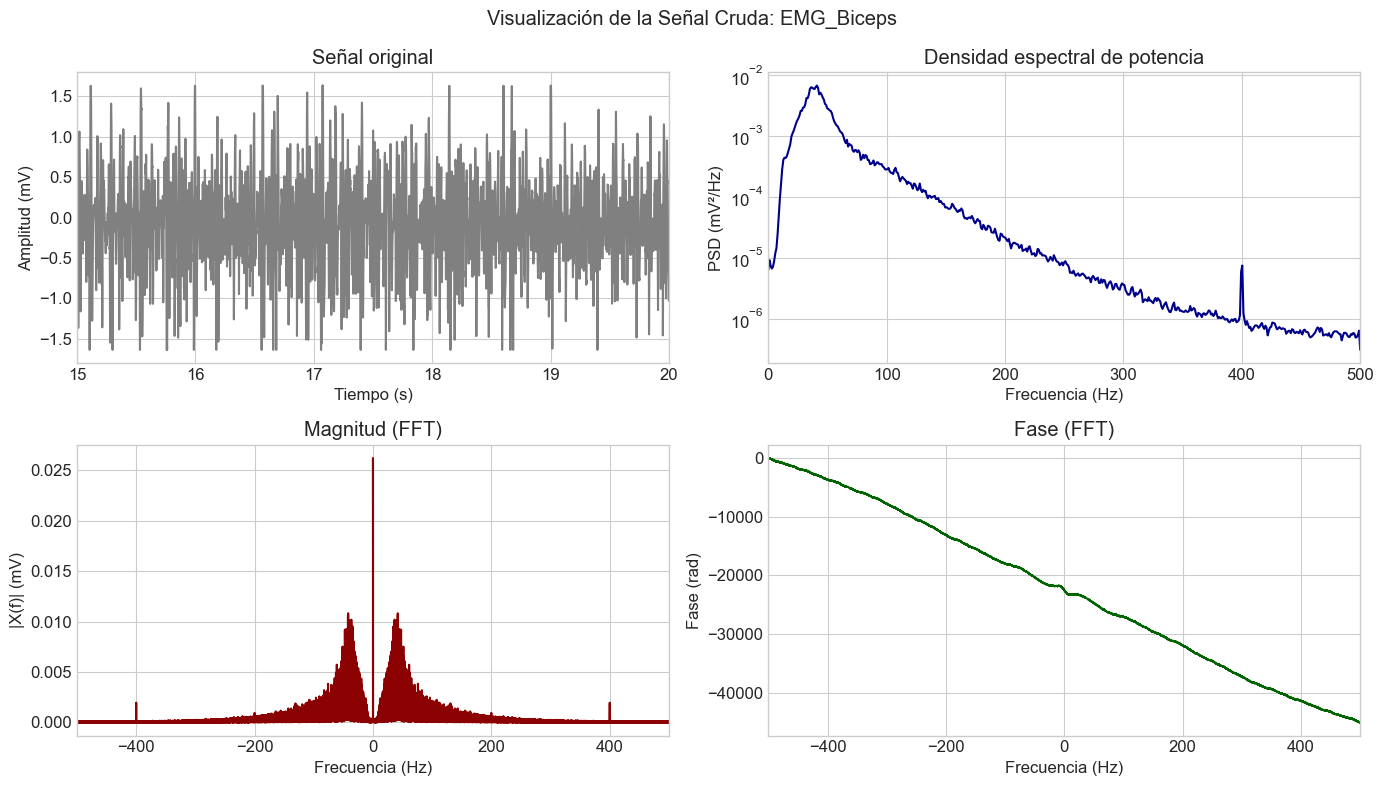

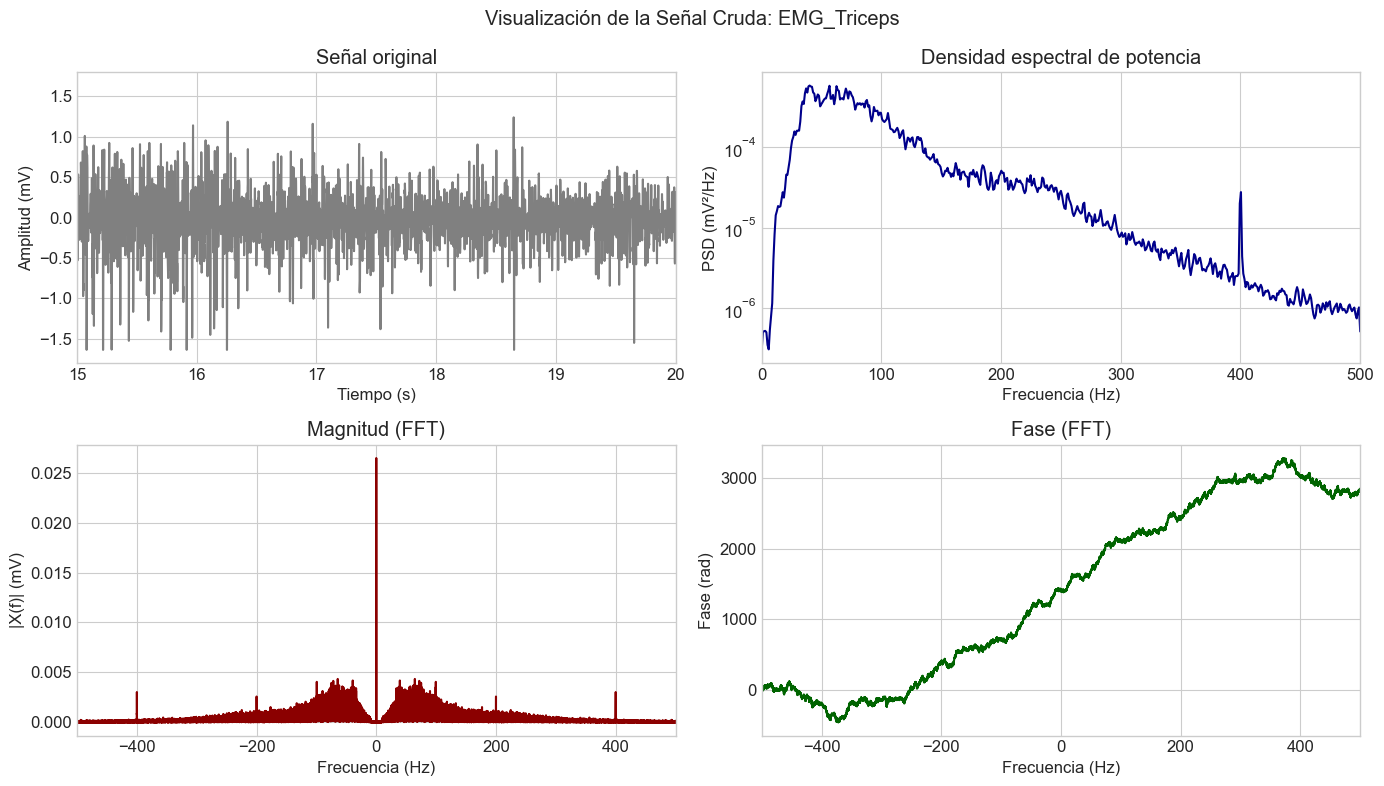

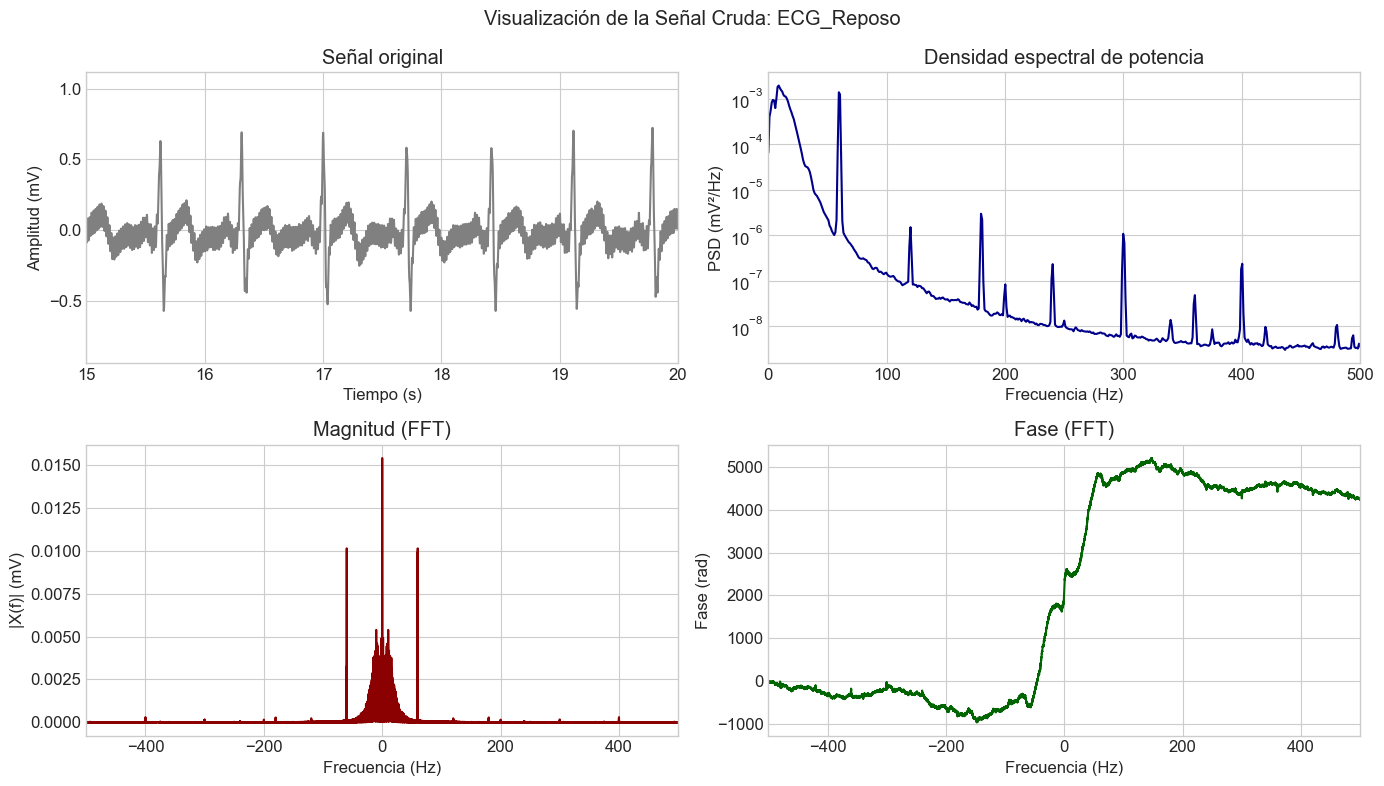

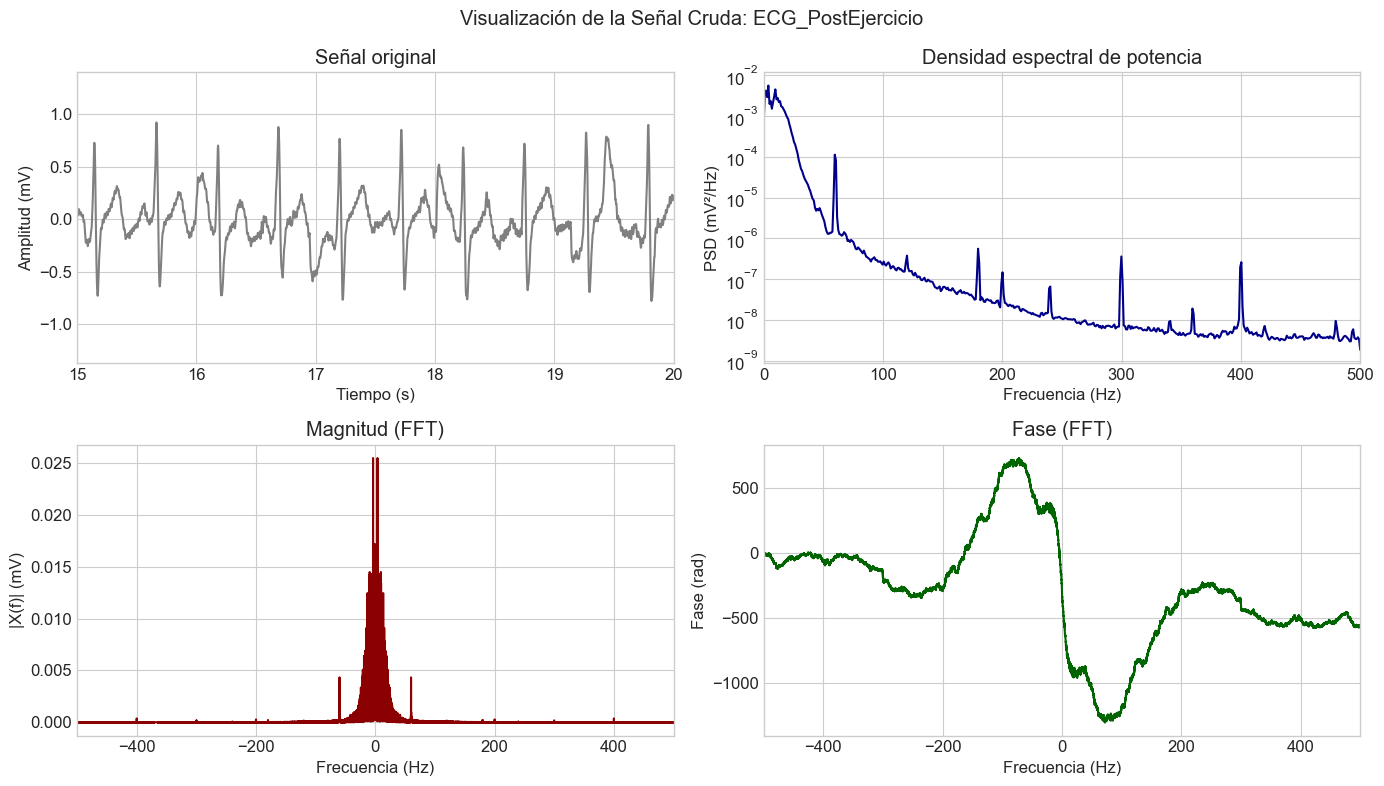

In [110]:
# 5. Visualización de Señales Crudas
for nombre, datos in SEÑALES_CRUDAS.items():
    senal = datos['senal_mv']
    tiempo = datos['tiempo']

    fig, axs = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Visualización de la Señal Cruda: {nombre}')
    axs = axs.ravel()

    # Señal original
    axs[0].plot(tiempo, senal, color='gray')
    axs[0].set_title('Señal original')
    axs[0].set_xlabel('Tiempo (s)')
    axs[0].set_ylabel('Amplitud (mV)')
    axs[0].grid(True)
    axs[0].set_xlim(15,20)

    # PSD (Welch)
    f, psd = welch(senal, fs=Fs, nperseg=1024)
    axs[1].semilogy(f, psd, color='darkblue')
    axs[1].set_title('Densidad espectral de potencia')
    axs[1].set_xlabel('Frecuencia (Hz)')
    axs[1].set_ylabel('PSD (mV²/Hz)')
    axs[1].grid(True)
    axs[1].set_xlim(0, Fs/2)

    # FFT con normalización y centrado
    N = len(senal)
    fft_vals = np.fft.fftshift(np.fft.fft(senal))
    fft_freq = np.fft.fftshift(np.fft.fftfreq(N, d=1/Fs))

    # Magnitud
    axs[2].plot(fft_freq, np.abs(fft_vals) / N, color='darkred')
    axs[2].set_title('Magnitud (FFT)')
    axs[2].set_xlabel('Frecuencia (Hz)')
    axs[2].set_ylabel('|X(f)| (mV)')
    axs[2].grid(True)
    axs[2].set_xlim(-Fs/2, Fs/2)

    # Fase (unwrapped)
    fase = np.unwrap(np.angle(fft_vals))
    axs[3].plot(fft_freq, fase, color='darkgreen')
    axs[3].set_title('Fase (FFT)')
    axs[3].set_xlabel('Frecuencia (Hz)')
    axs[3].set_ylabel('Fase (rad)')
    axs[3].grid(True)
    axs[3].set_xlim(-Fs/2, Fs/2)

    plt.tight_layout()
    plt.show()


## 3) Aplicación y Evaluación de Filtros Pre-diseñados

En esta fase, se evaluará el rendimiento de un conjunto de filtros digitales (FIR e IIR) cuyos coeficientes han sido previamente diseñados y exportados a archivos `.csv`. El objetivo es aplicar estos filtros a las señales EMG y ECG crudas para determinar cuál de ellos ofrece la mejor relación entre eliminación de ruido y preservación de las características fisiológicas de interés.

El análisis se estructura en dos partes principales, una para cada tipo de señal:

1.  **Análisis de Filtros EMG:** Se aplicarán cuatro filtros pasa-banda (dos FIR y dos IIR) a las señales de bíceps y tríceps. Se comparará su capacidad para aislar la actividad muscular del ruido de fondo.

2.  **Análisis de Filtros ECG:** Se aplicará un conjunto diferente de cuatro filtros a las señales de reposo y post-ejercicio. Se evaluará su eficacia para eliminar la deriva de línea base y el ruido de alta frecuencia, preservando al mismo tiempo la morfología del complejo P-QRS-T.

Para cada señal, la evaluación será tanto cualitativa, a través de la inspección visual de los resultados, como cuantitativa, mediante el cálculo de la **Relación Señal-Ruido (SNR)**. Este enfoque nos permitirá justificar de manera objetiva la selección del filtro más adecuado para cada aplicación biomédica [3, 4]


---
## **SECCIÓN EMG**

---

### 3.1) Diseño de Filtros EMG en `pyfdax`
---

Ahora que hemos justificado la necesidad de los filtros, procederemos a diseñar los **cuatro filtros de comparación para la señal EMG**.

---

#### Tabla Resumen de Filtros Diseñados

---

<div style="display: flex; align-items: flex-start; gap: 20px;">

<div style="flex: 1;">

##### 1️⃣ FIR_Equiripple_pasa_banda_EMG.csv
| Parámetro | Valor |
|:-----------|:-------|
| **Tipo de Respuesta** | Bandpass |
| **Tipo de Diseño** | FIR |
| **Método** | Equiripple |
| **Orden** | Minimum |
| **Frecuencias (Hz)** | f_SB=10, f_PB=20, f_PB2=450, f_SB2=460 |
| **Ripple (dB)** | A_SB=60, A_PB=1, A_SB2=60 |
| **β (Kaiser)** | — |

</div>

<div style="flex: 1;">
  <img src="Imagenes/Filtros/EMG/FIR_Equiripple_pasa_banda_EMG/magnitud.jpg" width="300"/><br>
  <img src="Imagenes/Filtros/EMG/FIR_Equiripple_pasa_banda_EMG/fase.jpg" width="300"/><br>
  <img src="Imagenes/Filtros/EMG/FIR_Equiripple_pasa_banda_EMG/polos_ceros.jpg" width="300"/>
</div>

</div>

---

<div style="display: flex; align-items: flex-start; gap: 20px;">

<div style="flex: 1;">

##### 2️⃣ FIR_Kaiser_pasa_banda_EMG.csv
| Parámetro | Valor |
|:-----------|:-------|
| **Tipo de Respuesta** | Bandpass |
| **Tipo de Diseño** | FIR |
| **Método** | Kaiser |
| **Orden** | Minimum |
| **Frecuencias (Hz)** | f_SB=10, f_PB=20, f_PB2=450, f_SB2=460 |
| **Ripple (dB)** | A_SB=60, A_PB=1, A_SB2=60 |
| **β (Kaiser)** | 5.65 |

</div>

<div style="flex: 1;">
  <img src="Imagenes/Filtros/EMG/FIR_Kaiser_pasa_banda_EMG/magnitud.jpg" width="300"/><br>
  <img src="Imagenes/Filtros/EMG/FIR_Kaiser_pasa_banda_EMG/fase.jpg" width="300"/><br>
  <img src="Imagenes/Filtros/EMG/FIR_Kaiser_pasa_banda_EMG/polos_ceros.jpg" width="300"/>
</div>

</div>

---

<div style="display: flex; align-items: flex-start; gap: 20px;">

<div style="flex: 1;">

##### 3️⃣ IIR_Butterworth_pasa_banda_EMG.csv
| Parámetro | Valor |
|:-----------|:-------|
| **Tipo de Respuesta** | Bandpass |
| **Tipo de Diseño** | IIR |
| **Método** | Butterworth |
| **Orden (N)** | 4 |
| **Frecuencias (Hz)** | f_PB=20, f_PB2=450 |
| **Ripple (dB)** | — |
| **β (Kaiser)** | — |

</div>

<div style="flex: 1;">
  <img src="Imagenes/Filtros/EMG/IIR_Butterworth_pasa_banda_EMG/magnitud.jpg" width="300"/><br>
  <img src="Imagenes/Filtros/EMG/IIR_Butterworth_pasa_banda_EMG/fase.jpg" width="300"/><br>
  <img src="Imagenes/Filtros/EMG/IIR_Butterworth_pasa_banda_EMG/polos_ceros.jpg" width="300"/>
</div>

</div>

---

<div style="display: flex; align-items: flex-start; gap: 20px;">

<div style="flex: 1;">

##### 4️⃣ IIR_Eliptico_pasa_banda_EMG.csv
| Parámetro | Valor |
|:-----------|:-------|
| **Tipo de Respuesta** | Bandpass |
| **Tipo de Diseño** | IIR |
| **Método** | Elliptic |
| **Orden (N)** | 4 |
| **Frecuencias (Hz)** | f_PB=20, f_PB2=450 |
| **Ripple (dB)** | A_SB=60, A_PB=1 |
| **β (Kaiser)** | — |

</div>

<div style="flex: 1;">
  <img src="Imagenes/Filtros/EMG/IIR_Eliptico_pasa_banda_EMG/magnitud.jpg" width="300"/><br>
  <img src="Imagenes/Filtros/EMG/IIR_Eliptico_pasa_banda_EMG/fase.jpg" width="300"/><br>
  <img src="Imagenes/Filtros/EMG/IIR_Eliptico_pasa_banda_EMG/polos_ceros.jpg" width="300"/>
</div>

</div>

---


### 3.2) Carga y Visualización de la Respuesta en Frecuencia de los Filtros EMG

El primer paso para validar nuestro diseño es cargar los coeficientes exportados desde `pyfdax` y graficar la respuesta en frecuencia de cada filtro. Esto nos permite confirmar visualmente que las bandas de paso, las bandas de atenuación y el rizado coinciden con nuestras especificaciones de diseño.


1.  **`FIR_EQ`**: Un filtro FIR Pasa-Banda diseñado con el método Equiripple.
2.  **`FIR_HA`**: Un filtro FIR Pasa-Banda diseñado con una ventana de Hamming.
3.  **`IIR_BT`**: Un filtro IIR Pasa-Banda diseñado con el método Butterworth.
4.  **`IIR_EL`**: Un filtro IIR Pasa-Banda diseñado con el método Elíptico.

Generaremos una gráfica de **Magnitud (en dB)** y **Fase** para cada uno de los cuatro filtros diseñados, presentadas lado a lado para una mejor comparación. En la gráfica de magnitud, incluiremos líneas de referencia en -1 dB y -60 dB para verificar rápidamente el cumplimiento de los requisitos de diseño.

--- Cargando y Visualizando Filtros EMG---
- Coeficientes para 'FIR Equiripple Pasa-Banda' cargados.


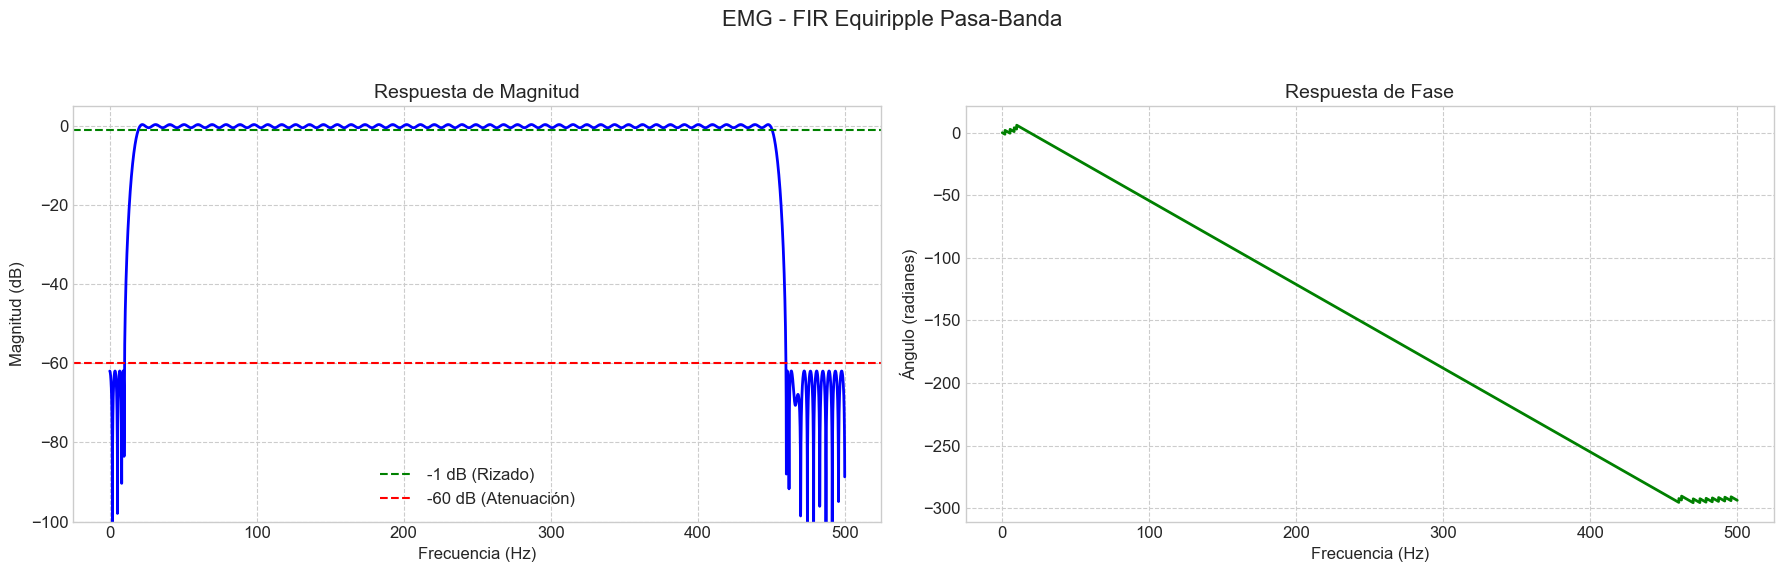

- Coeficientes para 'FIR Kaiser Pasa-Banda' cargados.


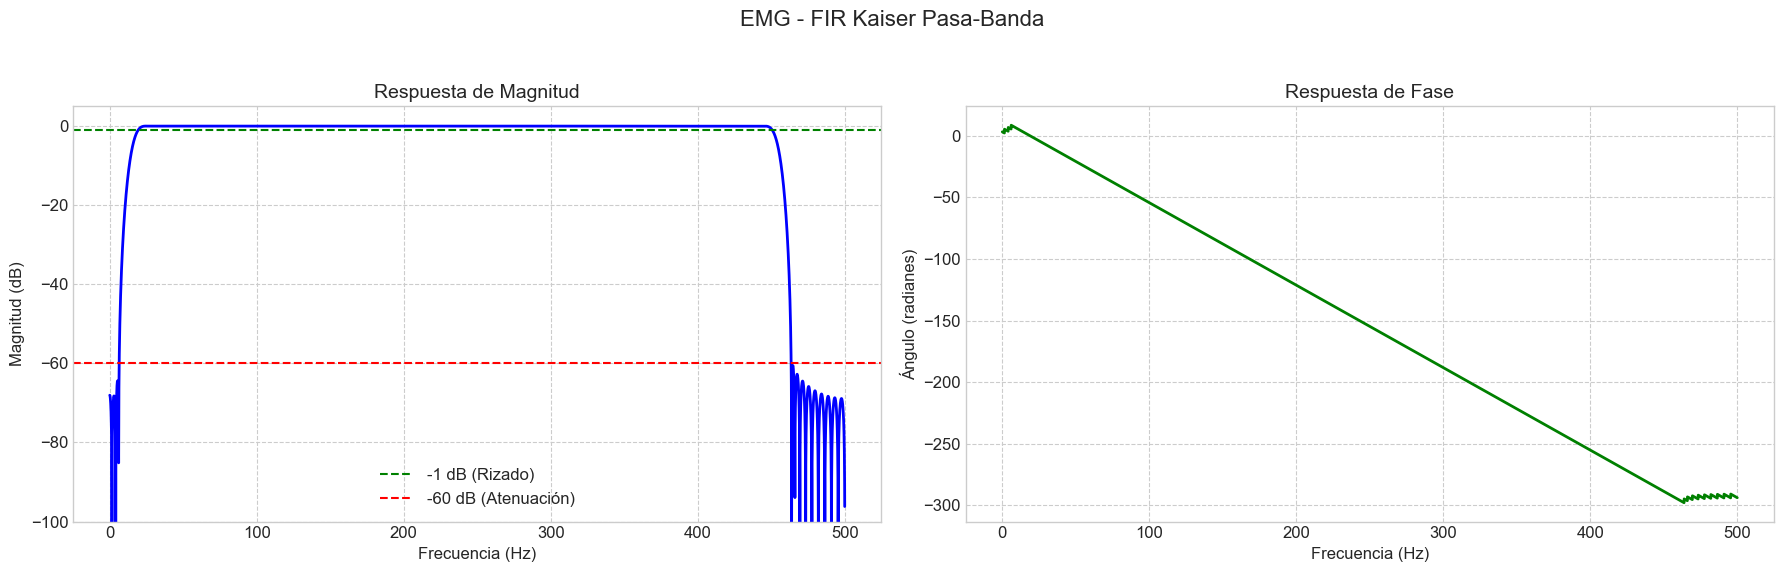

- Coeficientes para 'IIR Butterworth Pasa-Banda' cargados.


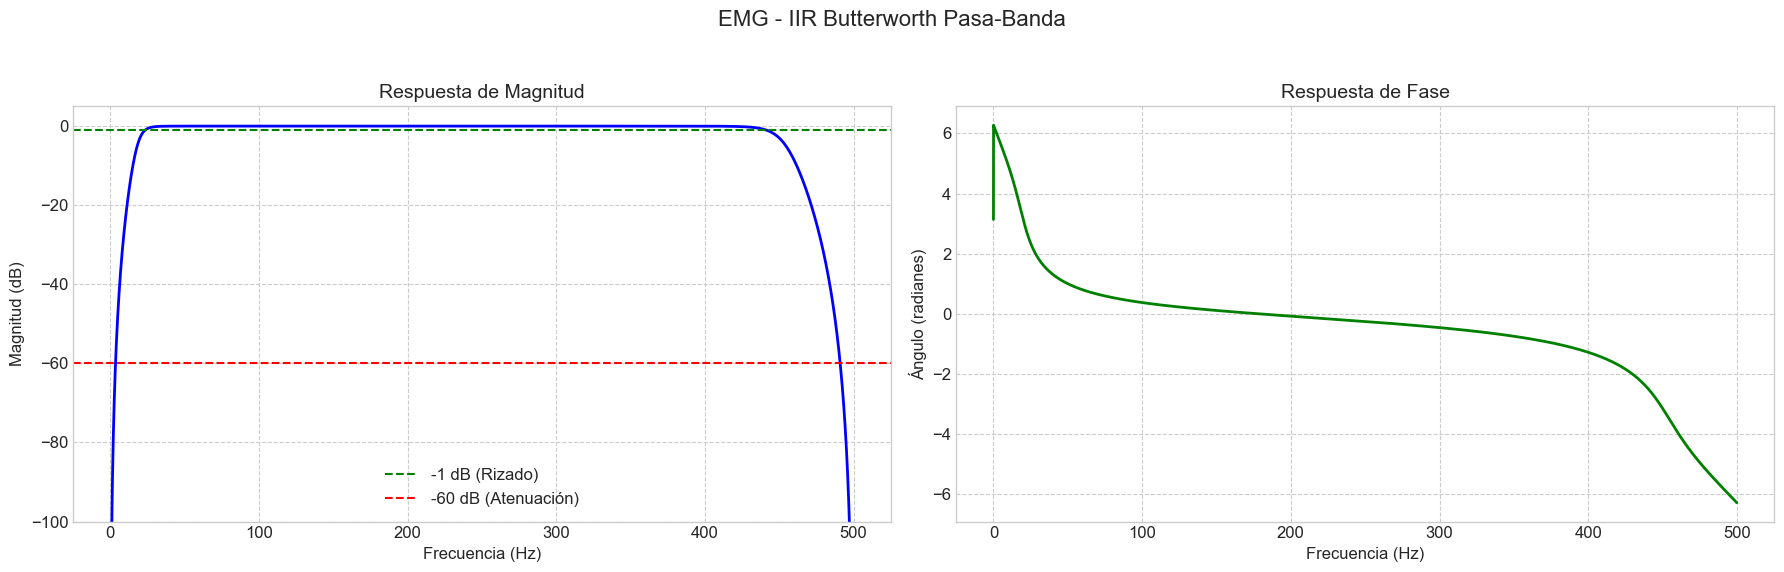

- Coeficientes para 'IIR Eliptico Pasa-Banda' cargados.


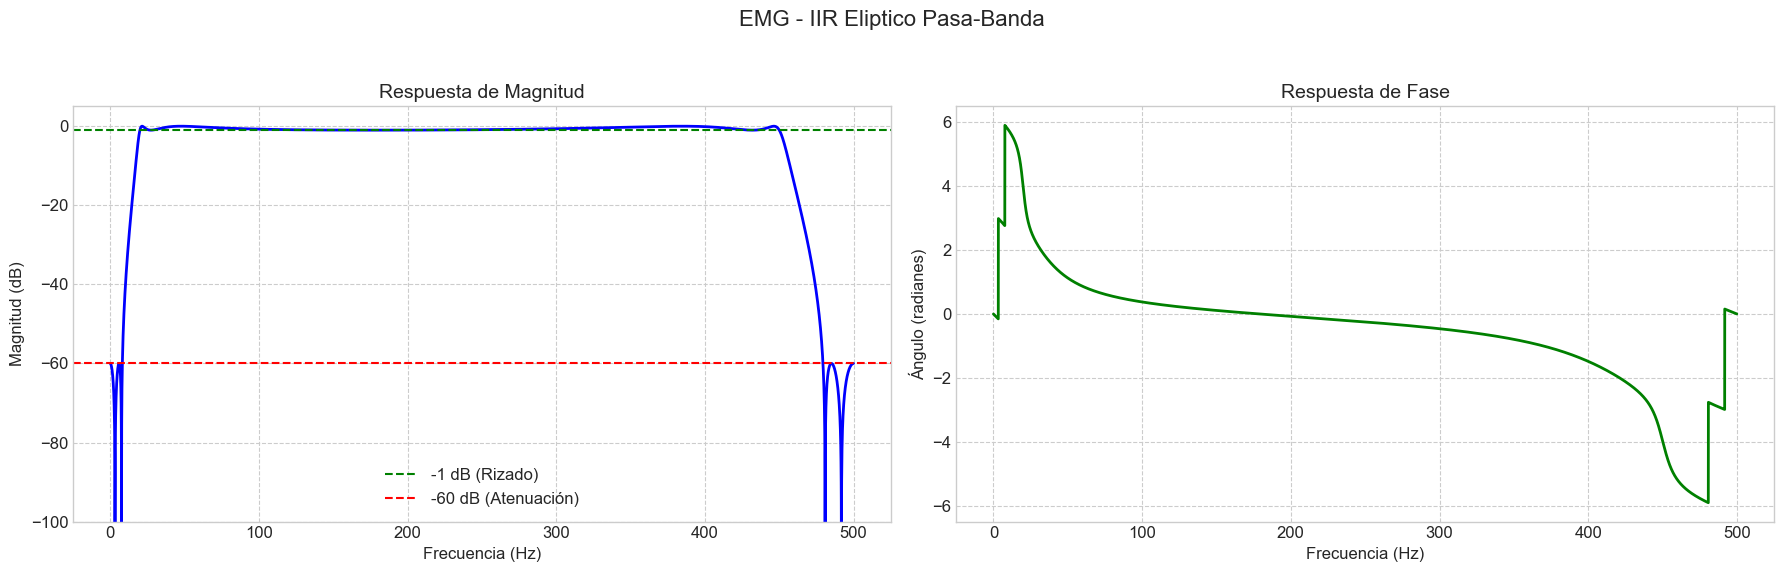


[ÉXITO] Los 4 filtros EMG se cargaron y visualizaron correctamente.


In [102]:
# Carga y Visualización de los filtros
# ------------------
# 1. DEFINICIONES DE FUNCIONES ---

COEF_DIR = 'Filtros_Pfyda'

def cargar_coeficientes_final(filepath):
    """
    Carga coeficientes desde un archivo CSV limpio sin encabezado.
    """
    try:
        data = np.loadtxt(filepath, delimiter=',')
        
        if data.ndim == 1:  # Caso FIR
            b = data
            a = np.array([1.0])
        else:  # Caso IIR
            b = data[:, 0]
            a = data[:, 1]
        return b, a
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo de coeficientes en '{filepath}'.")
        return None, None
    except Exception as e:
        print(f"Error al leer el archivo '{filepath}': {e}")
        return None, None

def plot_respuesta_filtro_unificada(b, a, fs, title, is_iir=False):
    """
    Función unificada que grafica la respuesta en frecuencia,
    convirtiendo IIRs a formato SOS para una visualización estable.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(title, fontsize=16)

    if is_iir:
        sos = tf2sos(b, a)
        w, h = sosfreqz(sos, worN=8000, fs=fs)
    else:
        w, h = freqz(b, a, worN=8000, fs=fs)
        
    ax1.plot(w, 20 * np.log10(np.abs(h) + 1e-9), 'b', linewidth=2)
    ax1.set_title('Respuesta de Magnitud', fontsize=14)
    ax1.set_ylabel('Magnitud (dB)', fontsize=12)
    ax1.set_xlabel('Frecuencia (Hz)', fontsize=12)
    ax1.grid(True, which='both', linestyle='--')
    ax1.axhline(-1, color='green', linestyle='--', label='-1 dB (Rizado)')
    ax1.axhline(-60, color='red', linestyle='--', label='-60 dB (Atenuación)')
    ax1.set_ylim(-100, 5)
    ax1.legend()

    angles = np.unwrap(np.angle(h))
    ax2.plot(w, angles, 'g', linewidth=2)
    ax2.set_title('Respuesta de Fase', fontsize=14)
    ax2.set_ylabel('Ángulo (radianes)', fontsize=12)
    ax2.set_xlabel('Frecuencia (Hz)', fontsize=12)
    ax2.grid(True, which='both', linestyle='--')
    
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    img_save_path = os.path.join('imagenes', f'filtro_{title.replace(" ", "_")}.png')
    plt.savefig(img_save_path, dpi=300)
    plt.show()

# 2. CÓDIGO DE EJECUCIÓN PRINCIPAL ---

FILTROS_EMG_PATHS = {
    'FIR Equiripple Pasa-Banda': os.path.join(COEF_DIR, 'FIR_Equiripple_pasa_banda_EMG.csv'),
    'FIR Kaiser Pasa-Banda': os.path.join(COEF_DIR, 'FIR_KAISER_pasa_banda_EMG.csv'),
    'IIR Butterworth Pasa-Banda': os.path.join(COEF_DIR, 'IIR_Butterworth_pasa_banda_EMG.csv'),
    'IIR Eliptico Pasa-Banda': os.path.join(COEF_DIR, 'IIR_Eliptico_pasa_banda_EMG.csv')
}
COEFICIENTES_EMG = {}

print("--- Cargando y Visualizando Filtros EMG---")
for nombre_descriptivo, ruta in FILTROS_EMG_PATHS.items():
    b, a = cargar_coeficientes_final(ruta)
    if b is not None:
        # Usaremos los nombres descriptivos como clave para el diccionario
        COEFICIENTES_EMG[nombre_descriptivo] = {'b': b, 'a': a}
        print(f"- Coeficientes para '{nombre_descriptivo}' cargados.")
        
        is_iir_flag = 'IIR' in nombre_descriptivo
        plot_respuesta_filtro_unificada(b, a, Fs, f'EMG - {nombre_descriptivo}', is_iir=is_iir_flag)

if len(COEFICIENTES_EMG) == 4:
    print("\n[ÉXITO] Los 4 filtros EMG se cargaron y visualizaron correctamente.")
else:
    print("\n[ADVERTENCIA] No se pudieron cargar todos los filtros. Revisa las rutas y nombres de archivo.")

### 3.3) Aplicación y Comparación Visual de los Filtros en las Señales EMG

Una vez validados los diseños, se aplica cada filtro a las señales EMG crudas para observar su efecto en el dominio del tiempo. Se utiliza un filtrado de fase cero (`filtfilt` para FIR y `sosfiltfilt` para IIR) para evitar la distorsión temporal de la señal [6].

A continuación, se presentan los resultados para las señales de bíceps y tríceps. Cada figura muestra los cuatro filtros aplicados en una cuadrícula de 2x2 para una comparación compacta y directa.


--- Procesando y visualizando filtros para: EMG_Biceps ---


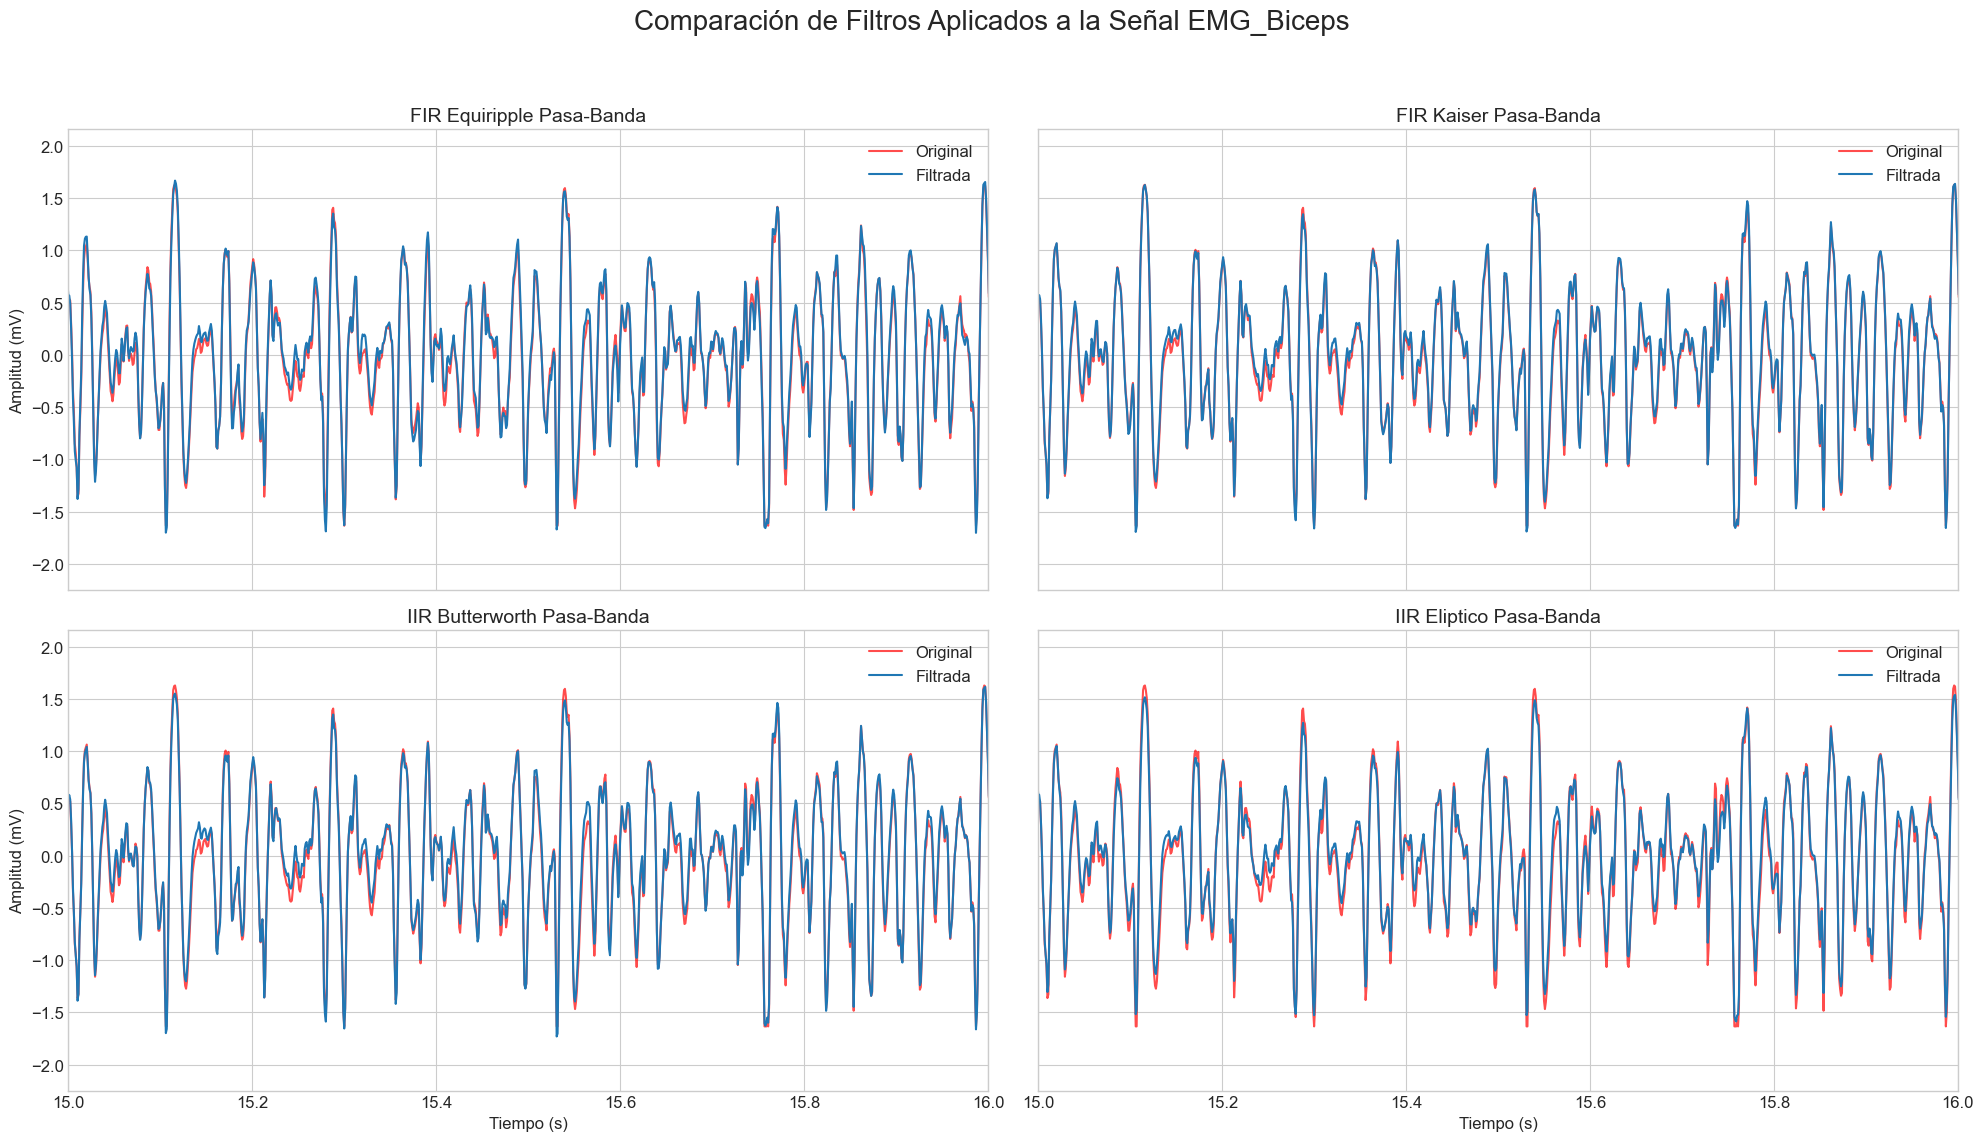

--- Procesando y visualizando filtros para: EMG_Triceps ---


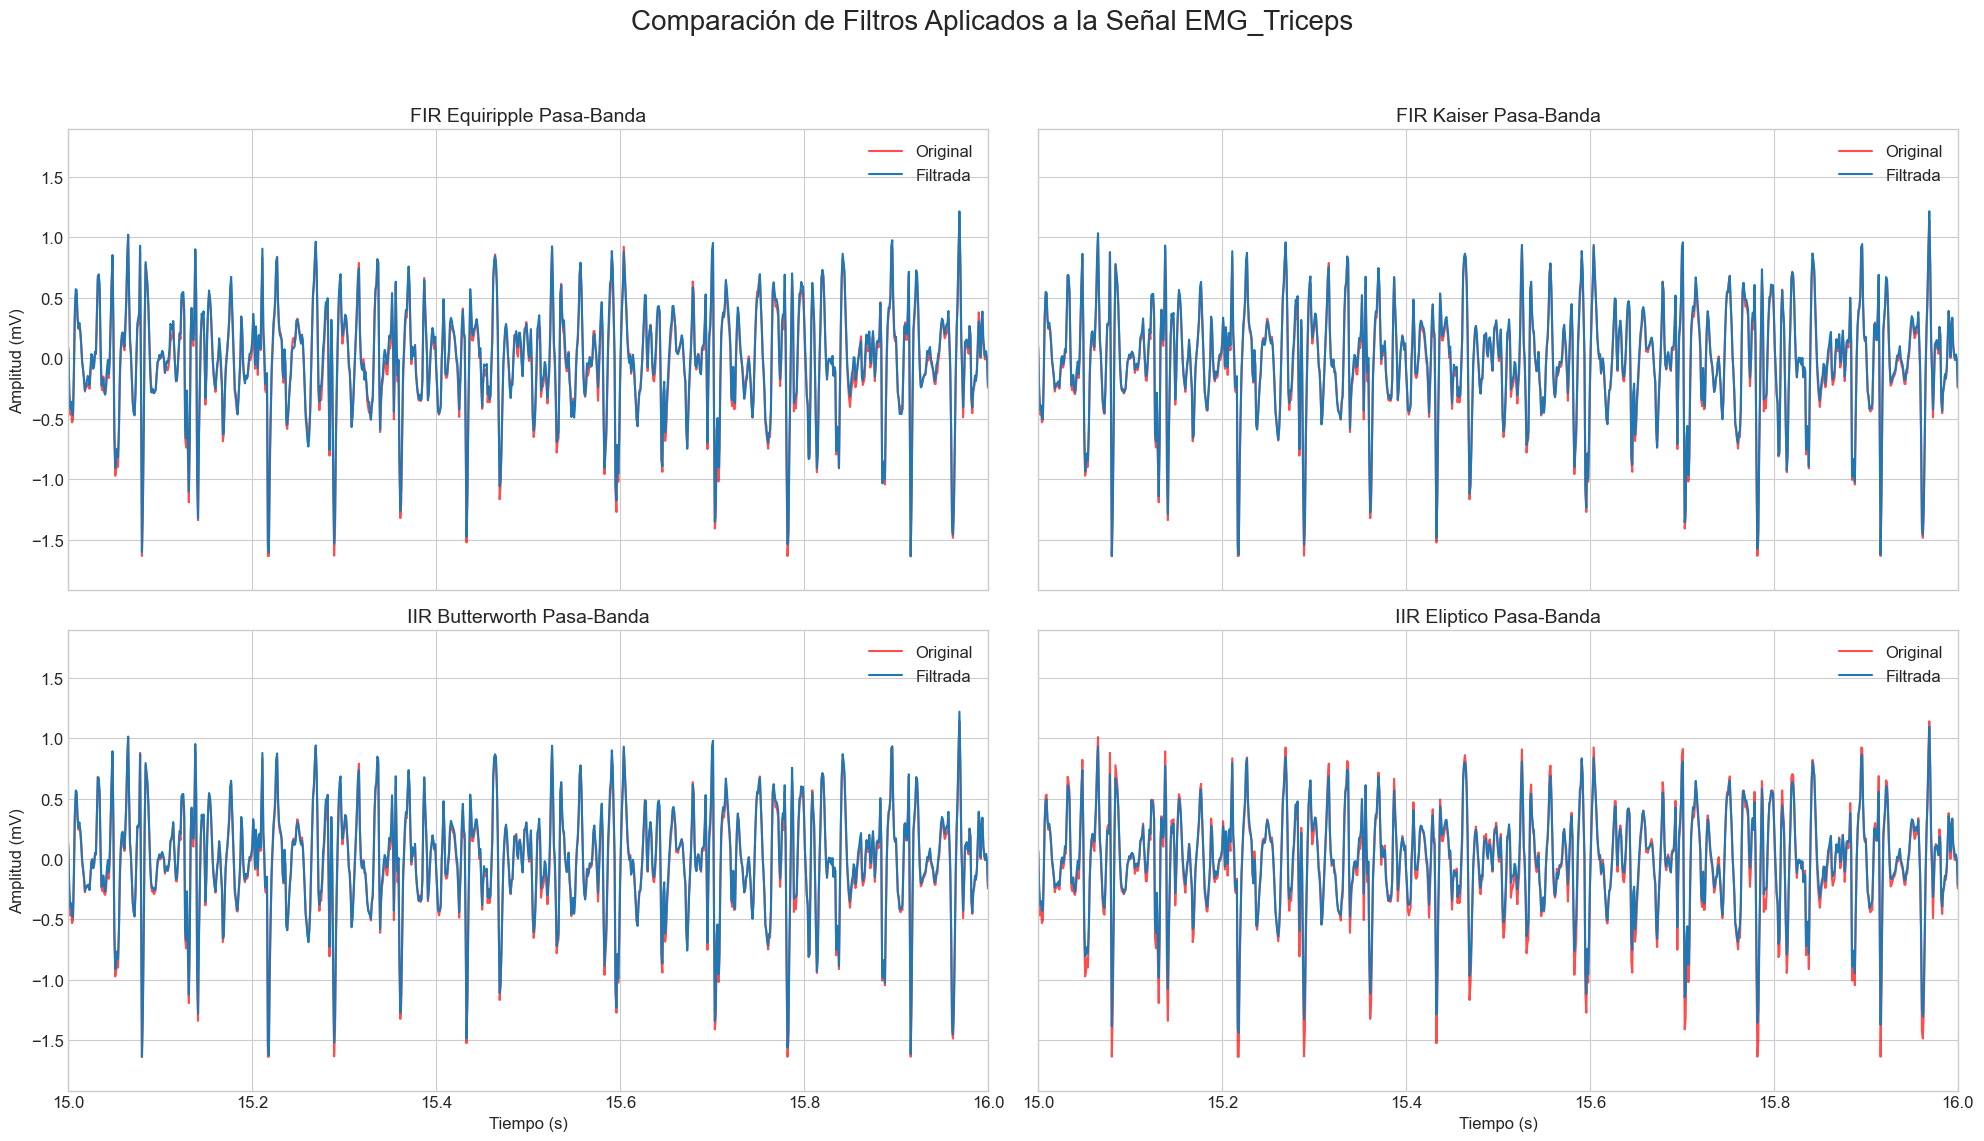

In [103]:
# Aplicación y Visualización Comparativa de Filtros EMG (2x2)

# Nombres de las señales EMG que vamos to procesar
senales_emg_a_procesar = ['EMG_Biceps', 'EMG_Triceps']

for nombre_senal in senales_emg_a_procesar:
    print(f"--- Procesando y visualizando filtros para: {nombre_senal} ---")
    
    # Extraer la señal y el tiempo correspondientes
    senal_original = SEÑALES_CRUDAS[nombre_senal]['senal_mv']
    tiempo = SEÑALES_CRUDAS[nombre_senal]['tiempo']
    
    # Crear una figura con una cuadrícula de 2x2
    fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharex=True, sharey=True)
    fig.suptitle(f'Comparación de Filtros Aplicados a la Señal {nombre_senal}', fontsize=20)
    
    # Aplanar el array de ejes para iterar fácilmente
    axes = axes.flatten()

    for i, (nombre_filtro, coefs) in enumerate(COEFICIENTES_EMG.items()):
        
        # Aplicar el filtro adecuado (FIR o IIR)
        if 'IIR' in nombre_filtro:
            sos = tf2sos(coefs['b'], coefs['a'])
            senal_filtrada = sosfiltfilt(sos, senal_original)
        else:
            senal_filtrada = filtfilt(coefs['b'], coefs['a'], senal_original)
        
        # Graficar en el subplot correspondiente
        ax = axes[i]
        ax.plot(tiempo, senal_original, color='red', alpha=0.7, label='Original')
        ax.plot(tiempo, senal_filtrada, label='Filtrada')
        ax.set_title(nombre_filtro, fontsize=14)
        ax.legend(loc='upper right')
        ax.grid(True)

        # Ajustar etiquetas de los ejes
        if i >= 2: # Eje X solo en la fila inferior
            ax.set_xlabel('Tiempo (s)', fontsize=12)
        if i % 2 == 0: # Eje Y solo en la columna izquierda
            ax.set_ylabel('Amplitud (mV)', fontsize=12)

    # Establecer límites de tiempo para la visualización
    plt.xlim(15, 16)
    
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### 3.4) Evaluación Cuantitativa - Cálculo de SNR y Tabla Comparativa EMG

Si bien la inspección visual es útil, no siempre revela las mejoras sutiles que introduce el filtrado. Para una evaluación objetiva, se utiliza la **Relación Señal-Ruido (SNR)**. Un SNR más alto indica un mejor rendimiento del filtro, ya que significa que la potencia de la señal de interés es mayor en comparación con la potencia del ruido de fondo.

Para la señal EMG, definiremos:
-   **"Señal"**: Un segmento de tiempo durante una contracción muscular fuerte.
-   **"Ruido"**: Un segmento de tiempo durante el reposo muscular inicial.

Calcularemos la potencia de ambos segmentos (usando la varianza, ya que la señal está centrada en cero) y obtendremos el SNR en decibelios (dB). Este proceso se repetirá para cada filtro aplicado a cada señal EMG, y los resultados se presentarán en una tabla comparativa para determinar el filtro más efectivo.

In [104]:
# Evaluación Cuantitativa EMG - Cálculo de SNR y Tabla Comparativa
# ------------------
# 1. DEFINICIONES DE FUNCIONES ---
def calcular_snr_emg(senal, tiempo, t_signal, t_noise):
    """
    Calcula la Relación Señal-Ruido (SNR) para una señal EMG.
    """
    # Encontrar los índices correspondientes a los períodos de tiempo
    idx_signal = np.where((tiempo >= t_signal[0]) & (tiempo < t_signal[1]))[0]
    idx_noise = np.where((tiempo >= t_noise[0]) & (tiempo < t_noise[1]))[0]

    if len(idx_signal) == 0 or len(idx_noise) == 0:
        return np.nan # No se pueden calcular si los segmentos están vacíos

    # Extraer los segmentos de la señal
    segmento_signal = senal[idx_signal]
    segmento_noise = senal[idx_noise]

    # Calcular la potencia como la varianza (poder medio cuadrático de la señal AC)
    potencia_signal = np.var(segmento_signal)
    potencia_noise = np.var(segmento_noise)

    if potencia_noise == 0:
        return np.inf # Evitar división por cero

    # Calcular SNR en dB
    snr_db = 10 * np.log10(potencia_signal / potencia_noise)
    return snr_db

# 2. Definición de los Períodos de Señal y Ruido para cada registro
# Estos valores se estiman observando los protocolos de adquisición de los laboratorios.
# (inicio_segundo, fin_segundo), así como por la visualización de la carga de la señal.
periodos = {
    'EMG_Biceps': {'signal': (25, 30), 'noise': (0, 10)},
    'EMG_Triceps': {'signal': (15, 20), 'noise': (0, 10)}
}

# 3. Cálculo y Almacenamiento de Resultados ---
resultados_snr = []
senales_a_filtrar_emg = ['EMG_Biceps', 'EMG_Triceps']

print("Calculando SNR para cada filtro y señal EMG...")
for nombre_senal in senales_a_filtrar_emg:
    fila_actual = {'Señal': nombre_senal}
    senal_cruda = SEÑALES_CRUDAS[nombre_senal]['senal_mv']
    tiempo = SEÑALES_CRUDAS[nombre_senal]['tiempo']
    
    # Obtener los períodos para esta señal
    t_signal = periodos[nombre_senal]['signal']
    t_noise = periodos[nombre_senal]['noise']

    # Calcular SNR para la señal cruda como línea base
    fila_actual['SNR Cruda'] = calcular_snr_emg(senal_cruda, tiempo, t_signal, t_noise)

    for nombre_filtro, coefs in COEFICIENTES_EMG.items():
        # Aplicar el filtro correspondiente
        if 'IIR' in nombre_filtro:
            sos = tf2sos(coefs['b'], coefs['a'])
            senal_filtrada = sosfiltfilt(sos, senal_cruda)
        else:
            senal_filtrada = filtfilt(coefs['b'], coefs['a'], senal_cruda)
        
        # Calcular SNR para la señal filtrada
        snr = calcular_snr_emg(senal_filtrada, tiempo, t_signal, t_noise)
        fila_actual[f'SNR {nombre_filtro}'] = snr
    
    resultados_snr.append(fila_actual)

# --- Presentación de la Tabla ---
df_snr_emg = pd.DataFrame(resultados_snr)

print("\nTabla Comparativa de SNR para Señales EMG (en dB):")
display(df_snr_emg.round(2))

Calculando SNR para cada filtro y señal EMG...

Tabla Comparativa de SNR para Señales EMG (en dB):


,Señal,SNR Cruda,SNR FIR Equiripple Pasa-Banda,SNR FIR Kaiser Pasa-Banda,SNR IIR Butterworth Pasa-Banda,SNR IIR Eliptico Pasa-Banda
0,EMG_Biceps,26.79,26.81,26.87,26.98,27.17
1,EMG_Triceps,21.57,21.48,21.62,21.65,21.42


### 3.5) Discusión de Resultados y Selección del Mejor Filtro EMG

La tabla de SNR proporciona una base cuantitativa clara para evaluar el rendimiento de cada filtro aplicado a las señales EMG.

Para la señal **`EMG_Biceps`**, que presentaba una alta calidad inicial (SNR Cruda de **26.79 dB**), todos los filtros lograron una mejora marginal. El filtro **IIR Elíptico (`IIR_EL`)** alcanzó el valor más alto (**27.17 dB**), confirmando su capacidad para mantener la banda útil con mínima distorsión.

En el caso de la señal **`EMG_Triceps`**, los resultados fueron más variados. Los filtros **IIR Butterworth (`IIR_BT`)** y **FIR Kaiser (`FIR_KAISER`)** mostraron una leve mejora, mientras que los métodos **Equiripple** y **Elíptico** redujeron ligeramente el SNR debido a su rizado característico en la banda de paso. El **Butterworth** obtuvo el mejor resultado (**21.65 dB**), mostrando un desempeño estable y predecible.

<br>

<div style="background-color:#e8f4fa; border-left: 4px solid #58a6ff; padding: 10px; border-radius: 6px;">
<b> Conclusión:</b>  
Considerando el rendimiento global y la eficiencia computacional, el filtro <b>IIR Butterworth (`IIR_BT`)</b> se selecciona como la opción óptima para el procesamiento de señales EMG.  
Ofrece una mejora consistente del SNR en ambas señales, requiere un orden bajo y su banda de paso <i>máximamente plana</i> garantiza una respuesta robusta y confiable.  
Para análisis donde se priorice la máxima preservación de amplitud en señales de alta calidad (como el bíceps), el filtro <b>IIR Elíptico</b> podría considerarse una alternativa complementaria.
</div>

---
## **SECCIÓN ECG**

---

### 3.6) Diseño de Filtros ECG en `pyfdax`
---

Para el análisis de las señales de ECG, se diseñó un conjunto de cuatro filtros con diferentes características para evaluar su capacidad de atenuar los artefactos preservando la morfología del latido. A continuación se detallan sus especificaciones y respuestas.

---

#### Tabla Resumen de Filtros Diseñados

---

<div style="display: flex; align-items/flex-start; gap: 20px;">
<div style="flex: 1;">

##### 1️⃣ FIR_Blackman_pasa_bajas_ECG.csv
| Parámetro | Valor |
|:-----------|:-------|
| **Tipo de Respuesta** | Lowpass |
| **Tipo de Diseño** | FIR |
| **Método** | Blackman |
| **Orden** | Minimum |
| **Frecuencias (Hz)** | f_PB=40, f_SB=50 |
| **Ripple (dB)** | A_PB=1, A_SB=80 |

</div>
<div style="flex: 1;">
  <img src="Imagenes/Filtros/ECG/FIR_Blackman_pasa_bajas_ECG/magnitud.png" width="300"/><br>
  <img src="Imagenes/Filtros/ECG/FIR_Blackman_pasa_bajas_ECG/fase.png" width="300"/><br>
  <img src="Imagenes/Filtros/ECG/FIR_Blackman_pasa_bajas_ECG/polos_ceros.png" width="300"/>
</div>
</div>

---

<div style="display: flex; align-items/flex-start; gap: 20px;">
<div style="flex: 1;">

##### 2️⃣ FIR_Hamming_pasa_bajas_ECG.csv
| Parámetro | Valor |
|:-----------|:-------|
| **Tipo de Respuesta** | Lowpass |
| **Tipo de Diseño** | FIR |
| **Método** | Hamming |
| **Orden** | Minimum |
| **Frecuencias (Hz)** | f_PB=40, f_SB=50 |
| **Ripple (dB)** | A_PB=1, A_SB=80 |

</div>
<div style="flex: 1;">
  <img src="Imagenes/Filtros/ECG/FIR_Hamming_pasa_bajas_ECG/magnitud.png" width="300"/><br>
  <img src="Imagenes/Filtros/ECG/FIR_Hamming_pasa_bajas_ECG/fase.png" width="300"/><br>
  <img src="Imagenes/Filtros/ECG/FIR_Hamming_pasa_bajas_ECG/polos_ceros.png" width="300"/>
</div>
</div>

---

<div style="display: flex; align-items/flex-start; gap: 20px;">
<div style="flex: 1;">

##### 3️⃣ IIR_Butter_rechaza_banda_ECG.csv
| Parámetro | Valor |
|:-----------|:-------|
| **Tipo de Respuesta** | Bandstop |
| **Tipo de Diseño** | IIR |
| **Método** | Butterworth |
| **Orden (N)** | 4 |
| **Frecuencias (Hz)** | f_SB=59, f_SB2=61 |
| **Ripple (dB)** | — |

</div>
<div style="flex: 1;">
  <img src="Imagenes/Filtros/ECG/IIR_Butter_rechaza_banda_ECG/magnitud.png" width="300"/><br>
  <img src="Imagenes/Filtros/ECG/IIR_Butter_rechaza_banda_ECG/fase.png" width="300"/><br>
  <img src="Imagenes/Filtros/ECG/IIR_Butter_rechaza_banda_ECG/polos_ceros.png" width="300"/>
</div>
</div>

---

<div style="display: flex; align-items/flex-start; gap: 20px;">
<div style="flex: 1;">

##### 4️⃣ IIR_Eliptico_pasa_baja_ECG.csv
| Parámetro | Valor |
|:-----------|:-------|
| **Tipo de Respuesta** | Lowpass |
| **Tipo de Diseño** | IIR |
| **Método** | Elliptic |
| **Orden (N)** | 4 |
| **Frecuencias (Hz)** | f_PB=40, f_SB=50 |
| **Ripple (dB)** | A_PB=1, A_SB=80 |

</div>
<div style="flex: 1;">
  <img src="Imagenes/Filtros/ECG/IIR_Eliptico_pasa_baja_ECG/magnitud.png" width="300"/><br>
  <img src="Imagenes/Filtros/ECG/IIR_Eliptico_pasa_baja_ECG/fase.png" width="300"/><br>
  <img src="Imagenes/Filtros/ECG/IIR_Eliptico_pasa_baja_ECG/polos_ceros.png" width="300"/>
</div>
</div>

---

### 3.7) Carga y Visualización de la Respuesta en Frecuencia de los Filtros ECG

El primer paso para validar nuestro diseño es cargar los coeficientes exportados desde `pyfdax` y graficar la respuesta en frecuencia de cada filtro. Esto nos permite confirmar visualmente que las bandas de paso, las bandas de atenuación y el rizado coinciden con nuestras especificaciones de diseño.


1.  **`FIR_BL`**: Un filtro FIR Pasa-Banda diseñado con el método Blackman.
2.  **`FIR_HM`**: Un filtro FIR Pasa-Banda diseñado con una ventana de Hamming.
3.  **`IIR_Notch`**: Un filtro IIR Notch diseñado con el método Butterworth.
4.  **`IIR_PB`**: Un filtro IIR Pasa-Banda diseñado con el método Elíptico.

Generaremos una gráfica de **Magnitud (en dB)** y **Fase** para cada uno de los cuatro filtros diseñados, presentadas lado a lado para una mejor comparación. En la gráfica de magnitud, incluiremos líneas de referencia en -1 dB y -60 dB para verificar rápidamente el cumplimiento de los requisitos de diseño.

--- Cargando y Visualizando Filtros ECG ---
- Coeficientes para 'FIR Blackman Pasa-Bajo' cargados.


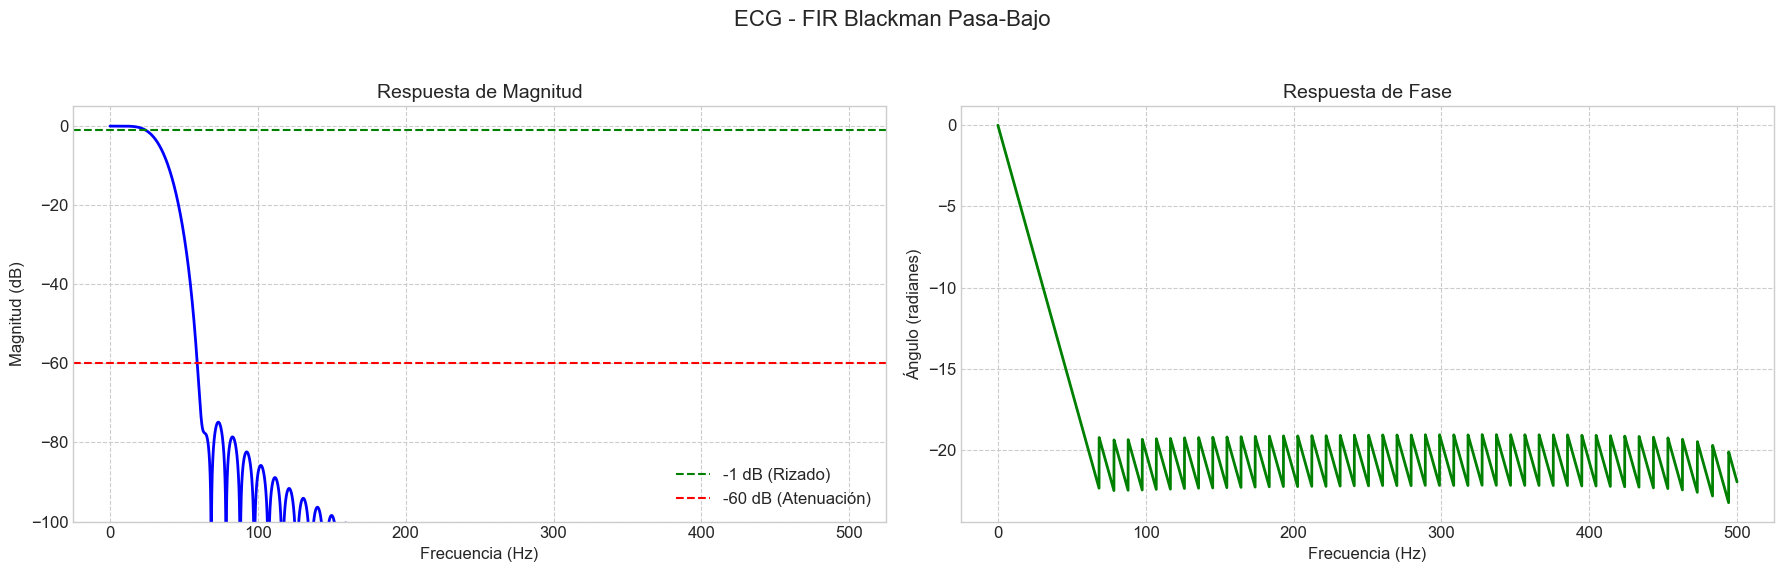

- Coeficientes para 'FIR Hamming Pasa-Bajo' cargados.


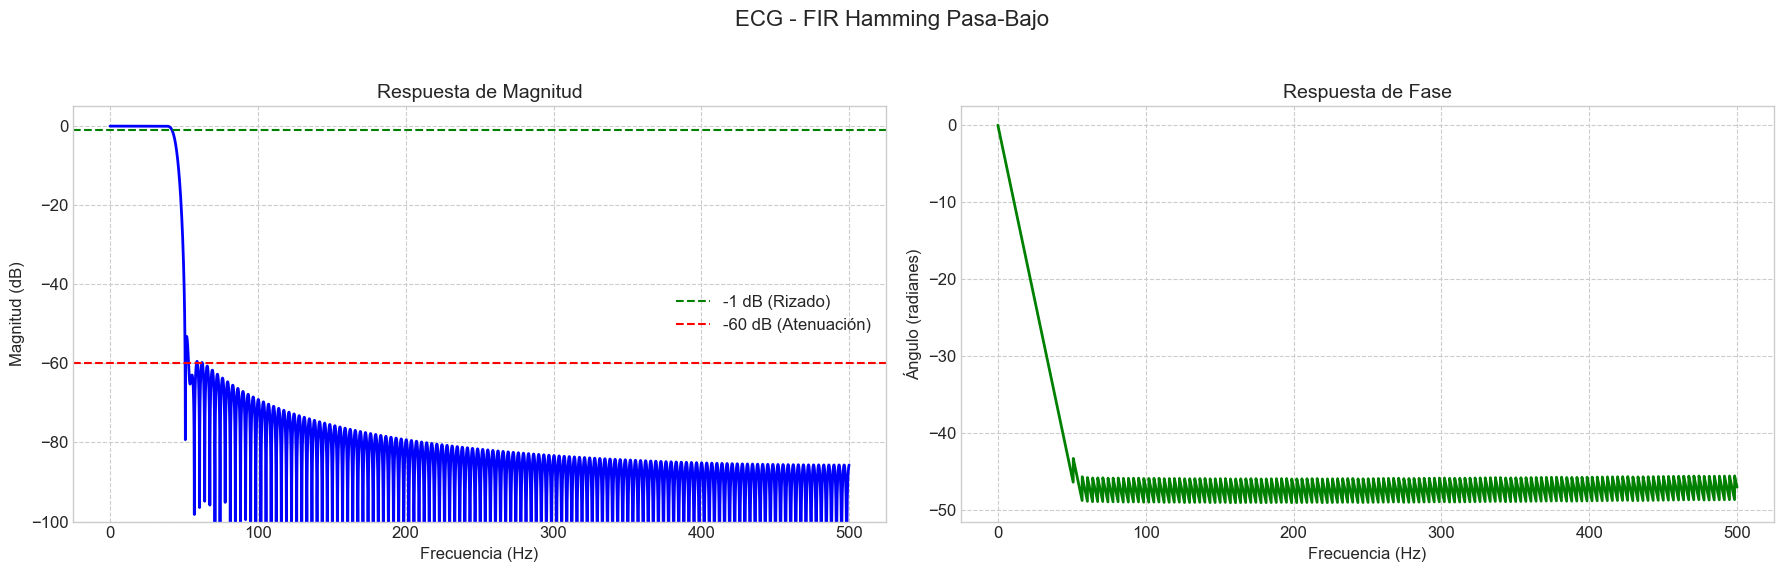

- Coeficientes para 'IIR Butterworth Rechaza-Banda' cargados.


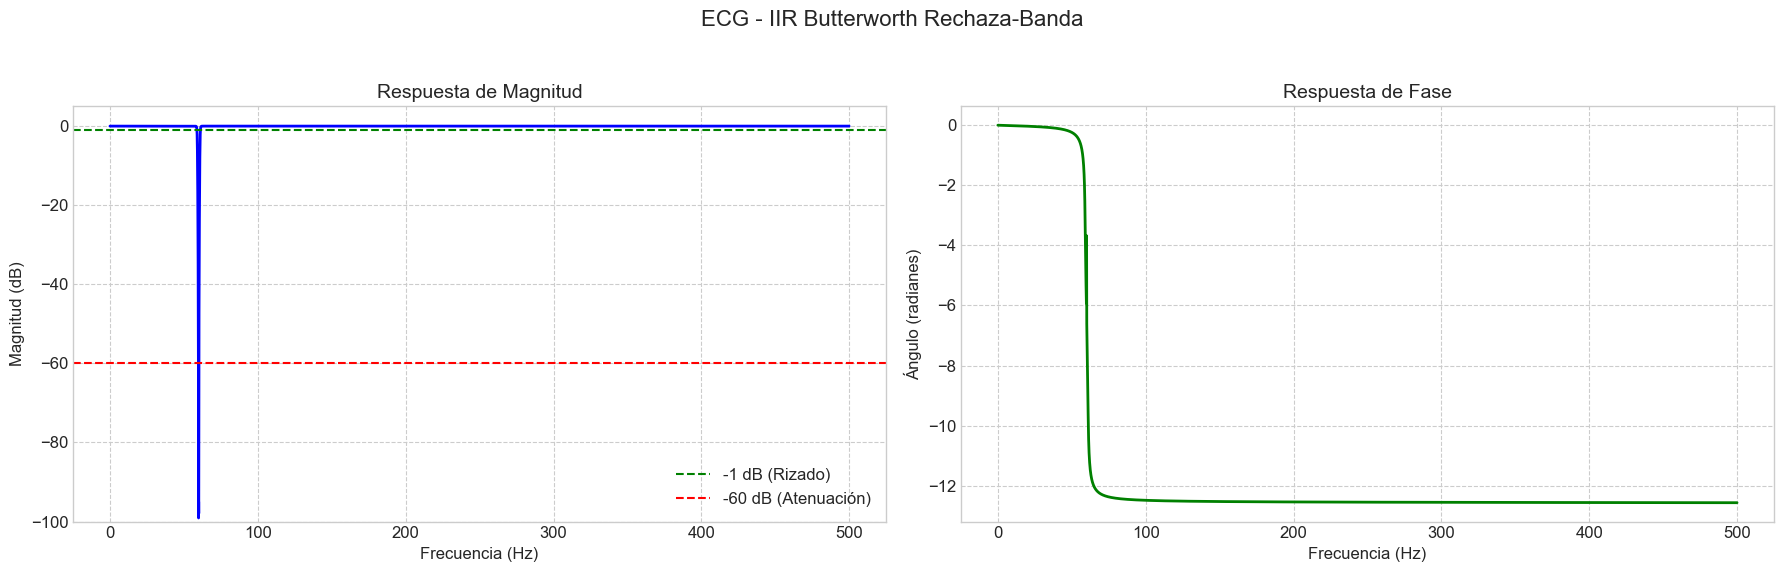

- Coeficientes para 'IIR Eliptico Pasa-Bajo' cargados.


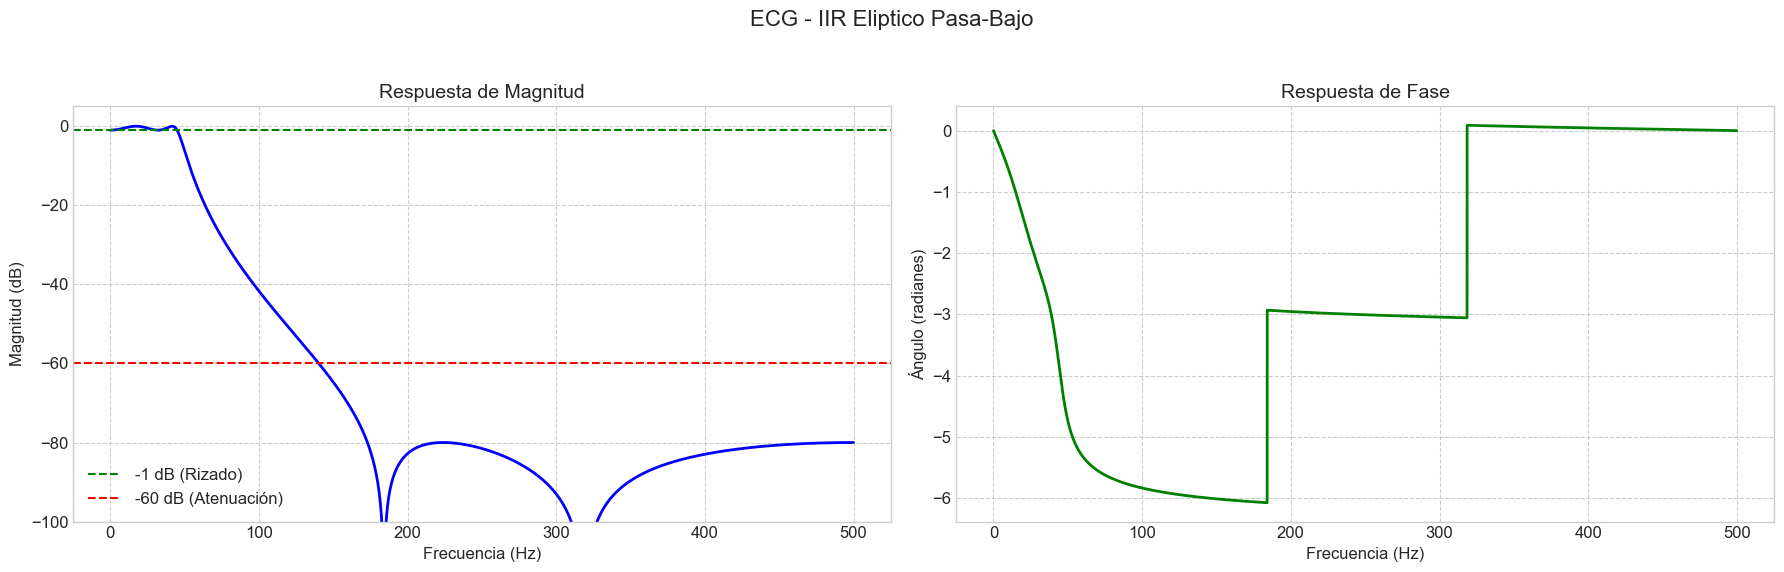


[ÉXITO] Los 4 filtros ECG se cargaron y visualizaron correctamente.


In [105]:
# Carga y Visualización de los Filtros ECG
# ------------------

# Define la ruta a la carpeta que contiene los archivos de coeficientes para ECG
path_filtros_ecg = 'Filtros_Pfyda'

# Nombres de archivo para los filtros ECG
nombres_archivos_filtros_ecg = {
    'FIR Blackman Pasa-Bajo': 'FIR_Blackman_pasa_bajas_ECG.csv',
    'FIR Hamming Pasa-Bajo': 'FIR_Hamming_pasa_bajas_ECG.csv',
    'IIR Butterworth Rechaza-Banda': 'IIR_Butter_rechaza_banda_ECG.csv',
    'IIR Eliptico Pasa-Bajo': 'IIR_Eliptico_pasa_baja_ECG.csv'
}

# Diccionario para almacenar los coeficientes de los filtros ECG
COEFICIENTES_ECG = {}

print("--- Cargando y Visualizando Filtros ECG ---")
for nombre_descriptivo, filename in nombres_archivos_filtros_ecg.items():
    filepath = os.path.join(path_filtros_ecg, filename)
    
    # Reutilizamos la función de carga que ya perfeccionamos
    b, a = cargar_coeficientes_final(filepath)
    
    if b is not None:
        COEFICIENTES_ECG[nombre_descriptivo] = {'b': b, 'a': a}
        print(f"- Coeficientes para '{nombre_descriptivo}' cargados.")
        
        # Reutilizamos la función de visualización
        is_iir_flag = 'IIR' in nombre_descriptivo
        plot_respuesta_filtro_unificada(b, a, Fs, f'ECG - {nombre_descriptivo}', is_iir=is_iir_flag)

if len(COEFICIENTES_ECG) == 4:
    print("\n[ÉXITO] Los 4 filtros ECG se cargaron y visualizaron correctamente.")
else:
    print("\n[ADVERTENCIA] No se pudieron cargar todos los filtros. Revisa las rutas y los nombres de los archivos.")

### 3.8) Aplicación y Comparación Visual de los Filtros en las Señales ECG

Con los diseños de los filtros ECG validados, se procede a aplicarlos a las señales de `ECG_Reposo` y `ECG_PostEjercicio`. El objetivo principal de esta visualización es evaluar cómo cada filtro afecta la morfología del latido cardíaco.

Se prestará especial atención a dos aspectos:
1.  **Corrección de la Línea Base:** Si el filtro elimina eficazmente la ondulación lenta (baseline wander).
2.  **Preservación de las Ondas:** Si el complejo P-QRS-T mantiene su forma característica sin distorsiones significativas.

Se utilizará un filtrado de fase cero para evitar desfases temporales. Los resultados para cada señal se presentarán en una cuadrícula de 2x2 para una comparación directa.

--- Procesando y visualizando filtros para: ECG_Reposo ---


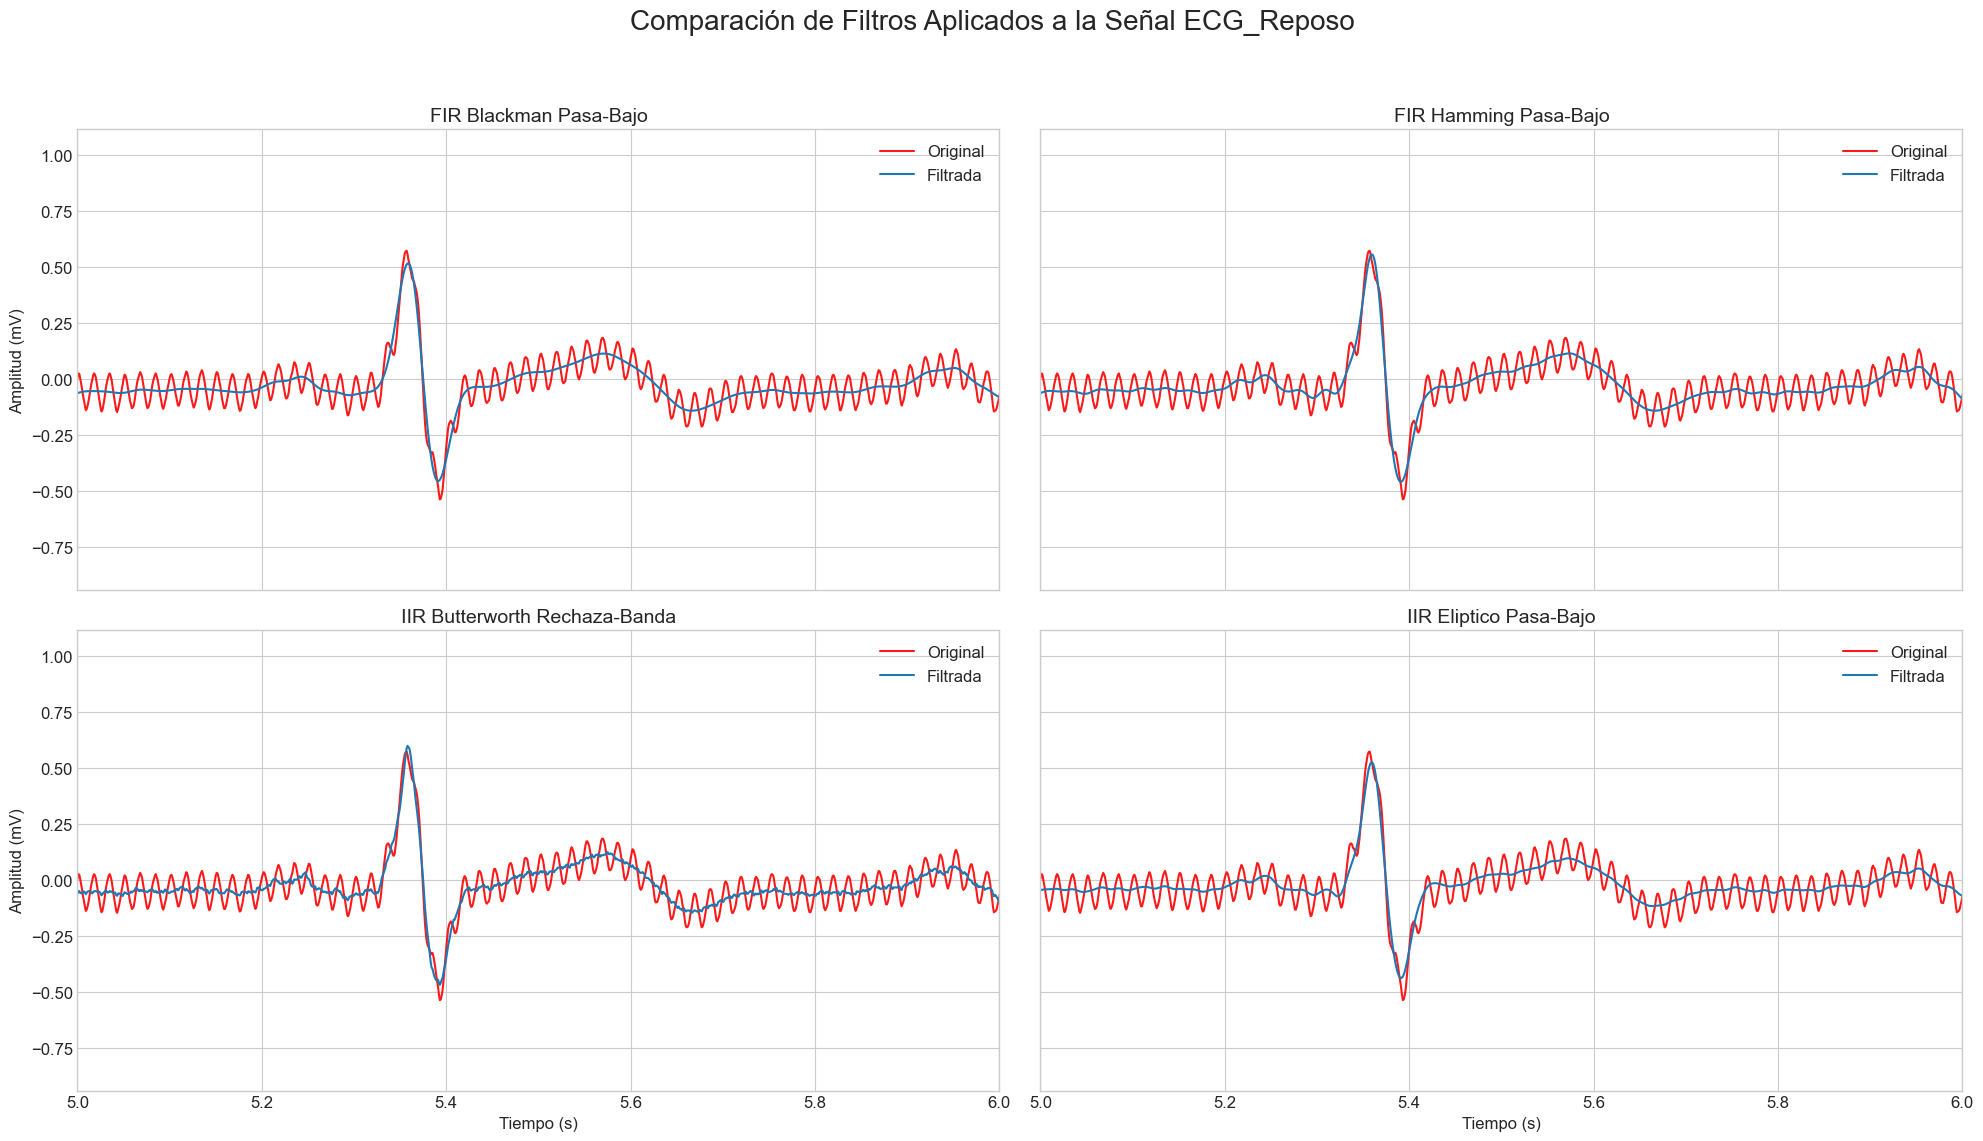

--- Procesando y visualizando filtros para: ECG_PostEjercicio ---


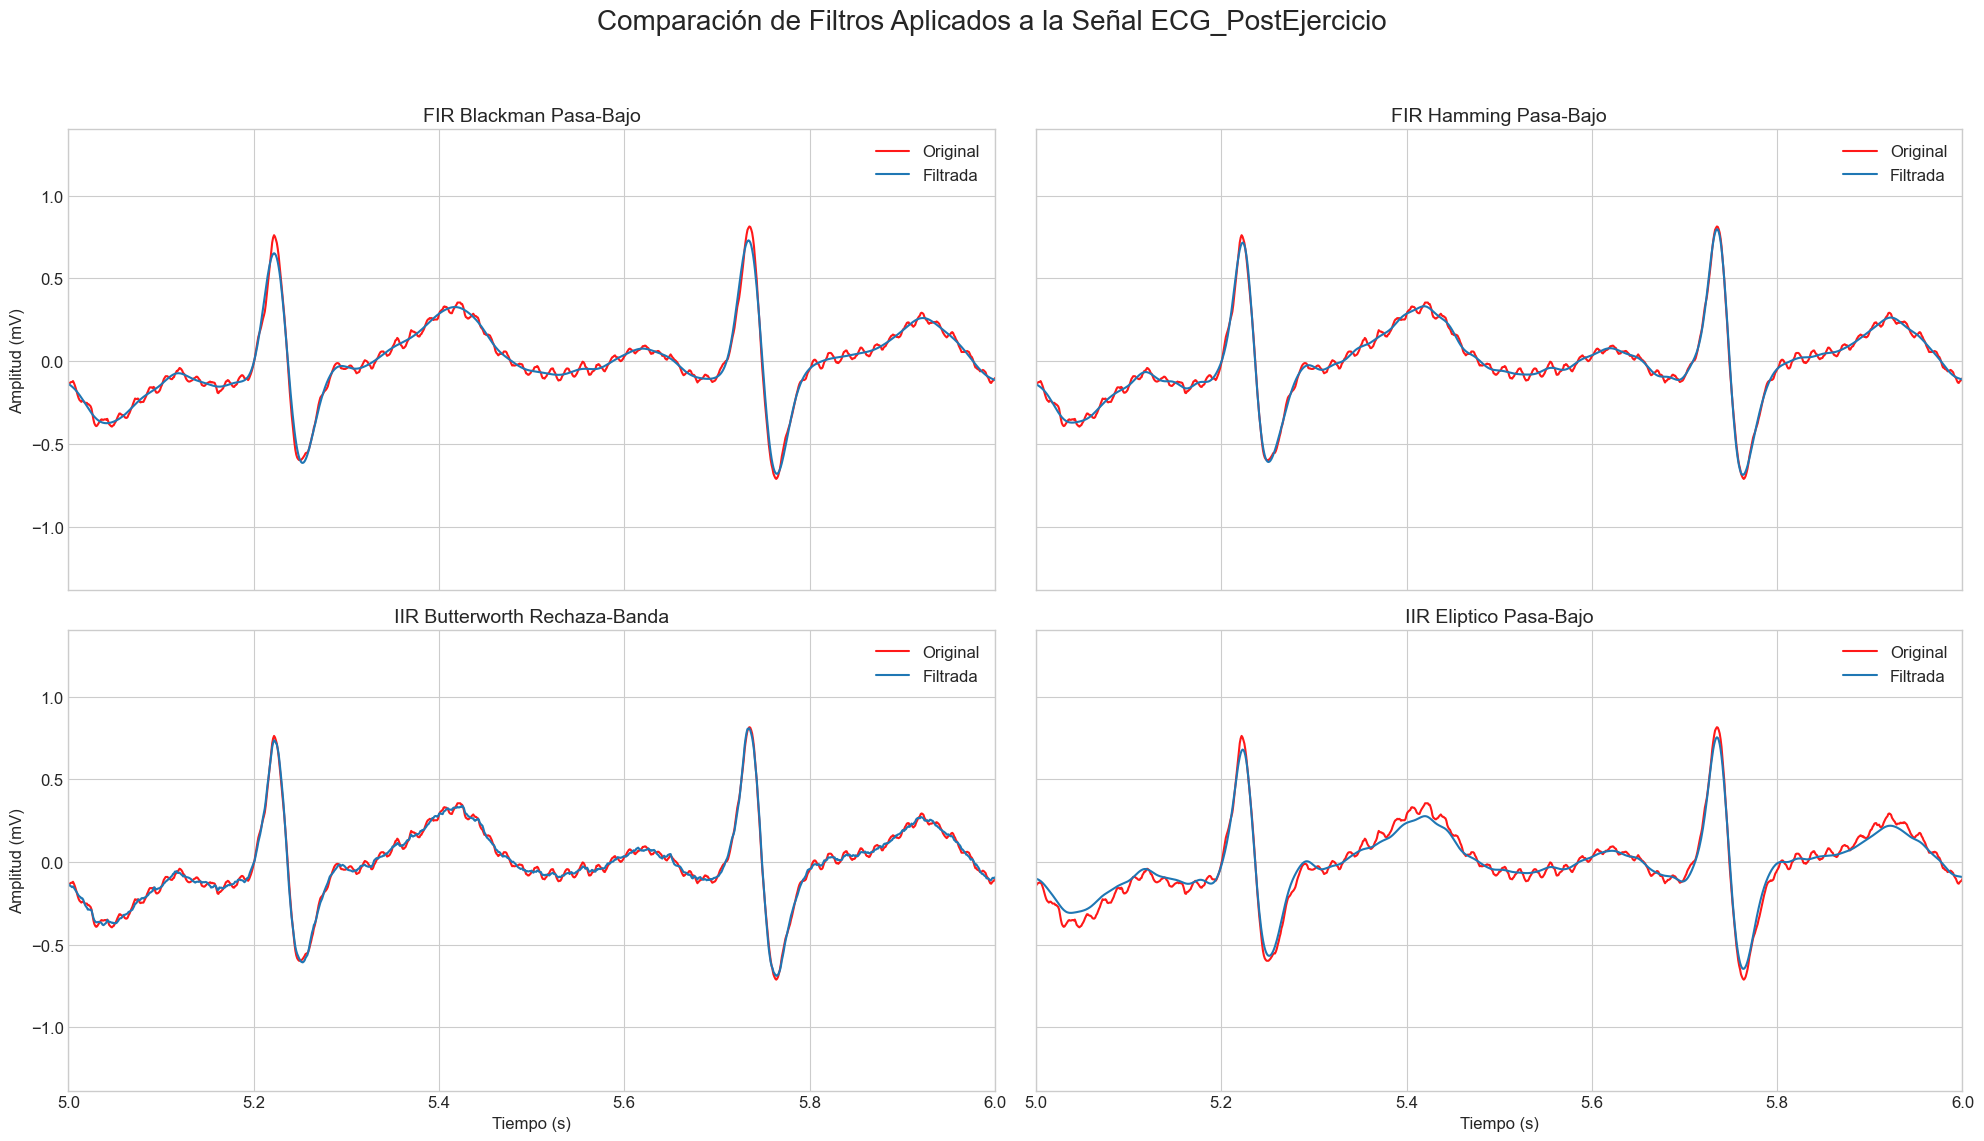

In [106]:
# Aplicación y Visualización Comparativa de Filtros ECG (2x2)
# ------------------

# Nombres de las señales ECG que vamos a procesar
senales_ecg_a_procesar = ['ECG_Reposo', 'ECG_PostEjercicio']

for nombre_senal in senales_ecg_a_procesar:
    print(f"--- Procesando y visualizando filtros para: {nombre_senal} ---")
    
    # Extraer la señal y el tiempo correspondientes
    senal_original = SEÑALES_CRUDAS[nombre_senal]['senal_mv']
    tiempo = SEÑALES_CRUDAS[nombre_senal]['tiempo']
    
    # Crear una figura con una cuadrícula de 2x2
    fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharex=True, sharey=True)
    fig.suptitle(f'Comparación de Filtros Aplicados a la Señal {nombre_senal}', fontsize=20)
    
    # Aplanar el array de ejes para iterar fácilmente
    axes = axes.flatten()

    for i, (nombre_filtro, coefs) in enumerate(COEFICIENTES_ECG.items()):
        
        # Aplicar el filtro adecuado (FIR o IIR)
        if 'IIR' in nombre_filtro:
            sos = tf2sos(coefs['b'], coefs['a'])
            senal_filtrada = sosfiltfilt(sos, senal_original)
        else:
            senal_filtrada = filtfilt(coefs['b'], coefs['a'], senal_original)
        
        # Graficar en el subplot correspondiente
        ax = axes[i]
        ax.plot(tiempo, senal_original, color='red', alpha=0.9, label='Original')
        ax.plot(tiempo, senal_filtrada, label='Filtrada')
        ax.set_title(nombre_filtro, fontsize=14)
        ax.legend(loc='upper right')
        ax.grid(True)

        # Ajustar etiquetas de los ejes
        if i >= 2: # Eje X solo en la fila inferior
            ax.set_xlabel('Tiempo (s)', fontsize=12)
        if i % 2 == 0: # Eje Y solo en la columna izquierda
            ax.set_ylabel('Amplitud (mV)', fontsize=12)

    # Establecer límites de tiempo para visualizar unos pocos latidos
    plt.xlim(5, 6) # Mostramos 2 latidos aproximadamente
    
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### 3.9) Evaluación Cuantitativa - Cálculo de SNR y Tabla Comparativa ECG

Para evaluar cuantitativamente los filtros de ECG, se calcula el SNR de una manera específica para esta señal. A diferencia de la EMG, aquí la "señal" y el "ruido" coexisten en cada ciclo cardíaco. Se define:

-   **"Señal"**: La potencia eléctrica concentrada en el complejo **QRS**, que es el evento de mayor energía y representa la despolarización ventricular.
-   **"Ruido"**: La potencia en el **segmento isoeléctrico T-P**, que es la línea base entre el final de un latido y el comienzo del siguiente.

El proceso implica detectar automáticamente todos los picos R para segmentar la señal en latidos individuales. Luego, se calcula la potencia promedio de los segmentos QRS y T-P a lo largo de todo el registro para obtener un valor de SNR robusto en decibelios (dB). Un filtro eficaz maximizará este valor, indicando que resalta el QRS mientras limpia la línea base.

In [114]:
# Evaluación Cuantitativa ECG
# ------------------
from scipy.signal import find_peaks

def calcular_snr_ecg_robusto(senal, fs=1000):
    """
    Calcula el SNR de una señal ECG utilizando un método de detección de picos R robusto
    basado en percentiles.
    """
    # 1. Encontrar los picos R con el método robusto.
    if len(senal) == 0: return np.nan
    umbral_pico = np.percentile(senal, 99) # Umbral basado en el percentil 99
    distancia_minima = int(0.6 * fs)      # Distancia de 600 ms entre picos
    
    picos_r, _ = find_peaks(senal, height=umbral_pico, distance=distancia_minima)
    
    if len(picos_r) < 2:
        return np.nan # No se puede calcular sin al menos dos latidos

    # El resto de la lógica para calcular potencias se mantiene igual
    ancho_qrs_muestras = int(0.1 * fs)
    potencias_signal = []
    potencias_noise = []

    for i in range(len(picos_r) - 1):
        inicio_qrs = picos_r[i] - ancho_qrs_muestras // 2
        fin_qrs = picos_r[i] + ancho_qrs_muestras // 2
        if inicio_qrs > 0 and fin_qrs < len(senal):
            segmento_qrs = senal[inicio_qrs:fin_qrs]
            potencias_signal.append(np.var(segmento_qrs))

        intervalo_rr = picos_r[i+1] - picos_r[i]
        inicio_ruido = picos_r[i] + int(intervalo_rr * 0.25)
        fin_ruido = picos_r[i] + int(intervalo_rr * 0.75)
        if fin_ruido < picos_r[i+1] and fin_ruido < len(senal):
             segmento_ruido = senal[inicio_ruido:fin_ruido]
             potencias_noise.append(np.var(segmento_ruido))

    if not potencias_signal or not potencias_noise:
        return np.nan

    potencia_media_signal = np.mean(potencias_signal)
    potencia_media_noise = np.mean(potencias_noise)

    if potencia_media_noise == 0:
        return np.inf

    snr_db = 10 * np.log10(potencia_media_signal / potencia_media_noise)
    return snr_db

# --- Cálculo y Almacenamiento de Resultados para ECG ---
resultados_snr_ecg = []
senales_a_filtrar_ecg = ['ECG_Reposo', 'ECG_PostEjercicio']

print("Calculando SNR para cada filtro y señal ECG (con método robusto)...")
for nombre_senal in senales_a_filtrar_ecg:
    fila_actual = {'Señal': nombre_senal}
    senal_cruda = SEÑALES_CRUDAS[nombre_senal]['senal_mv']
    
    # Usamos la nueva función robusta
    fila_actual['SNR Cruda'] = calcular_snr_ecg_robusto(senal_cruda, fs=Fs)

    for nombre_filtro, coefs in COEFICIENTES_ECG.items():
        if 'IIR' in nombre_filtro:
            sos = tf2sos(coefs['b'], coefs['a'])
            senal_filtrada = sosfiltfilt(sos, senal_cruda)
        else:
            senal_filtrada = filtfilt(coefs['b'], coefs['a'], senal_cruda)
        
        snr = calcular_snr_ecg_robusto(senal_filtrada, fs=Fs)
        fila_actual[f'SNR {nombre_filtro}'] = snr
    
    resultados_snr_ecg.append(fila_actual)

# --- Presentación de la Tabla ---
df_snr_ecg = pd.DataFrame(resultados_snr_ecg)

print("\nTabla Comparativa de SNR para Señales ECG (Resultados Corregidos):")
display(df_snr_ecg.round(2))

Calculando SNR para cada filtro y señal ECG (con método robusto)...

Tabla Comparativa de SNR para Señales ECG (Resultados Corregidos):


,Señal,SNR Cruda,SNR FIR Blackman Pasa-Bajo,SNR FIR Hamming Pasa-Bajo,SNR IIR Butterworth Rechaza-Banda,SNR IIR Eliptico Pasa-Bajo
0,ECG_Reposo,11.54,13.66,13.82,13.68,14.24
1,ECG_PostEjercicio,5.67,5.82,5.84,5.65,6.14


### 3.10) Discusión de Resultados y Selección del Mejor Filtro ECG

La tabla de SNR para las señales ECG revela información crucial sobre el rendimiento de los filtros en diferentes condiciones fisiológicas.

Para la señal **`ECG_Reposo`**, una grabación de alta calidad con un SNR crudo de 11.54 dB, todos los filtros demostraron ser efectivos, aumentando el SNR en más de 2 dB. El **filtro IIR Elíptico Pasa-Bajo (`IIR_PB`)** destacó como el de mejor rendimiento, alcanzando un SNR de **14.24 dB**.

Para la señal **`ECG_PostEjercicio`**, el SNR crudo fue significativamente menor (**5.67 dB**), lo cual es esperado fisiológicamente debido al incremento de artefactos musculares (EMG) y de movimiento. En este escenario más desafiante, el **filtro IIR Elíptico (`IIR_PB`)** nuevamente proporcionó la mayor mejora, alcanzando un SNR de **6.14 dB**.  
El filtro **Rechaza-Banda (Notch)**, por su parte, no evidenció una mejora relevante, lo que sugiere que la interferencia de **60 Hz** no era la fuente dominante de ruido.

---

<div style="background-color:#f2f4f7; padding:12px; border-radius:8px;">

**Conclusión:** El **filtro IIR Elíptico Pasa-Bajo (`IIR_PB`)** demostró el **mayor rendimiento y robustez** en ambas condiciones, tanto en la señal limpia de reposo como en la ruidosa de post-ejercicio. Gracias a su **alta selectividad** y capacidad de **maximizar la relación señal-ruido (SNR)** sin distorsionar las componentes de interés del ECG, se selecciona como la **opción superior para el preprocesamiento de señales ECG**.

</div>


---

## 4) Conclusiones Generales del Laboratorio

Este laboratorio ha demostrado con éxito el proceso completo de aplicación, comparación y selección de filtros digitales para dos tipos de señales biomédicas fundamentales: EMG y ECG.

Para las **señales EMG**, se concluyó que el **filtro IIR Butterworth Pasa-Banda** ofrecía el mejor equilibrio entre mejora del SNR, consistencia en diferentes grabaciones y eficiencia computacional. Se validó que el filtrado Pasa-Banda es esencial para aislar la actividad muscular de los artefactos de movimiento y el ruido electrónico.

Para las **señales ECG**, el **filtro IIR Elíptico Pasa-Bajo** fue seleccionado como el más efectivo. Demostró una capacidad superior para aumentar el SNR tanto en condiciones de reposo como en el desafiante entorno ruidoso de una señal post-ejercicio. El análisis cuantitativo confirmó la importancia de atenuar el ruido de alta frecuencia (como el EMG) y la deriva de la línea base para obtener una señal limpia.

Finalmente, este trabajo subraya la importancia de la evaluación cuantitativa (mediante SNR) como complemento indispensable a la inspección visual, permitiendo una selección de filtros objetiva y basada en datos.

---

## 5) Referencias

[1] Sörnmo L, Laguna P. Bioelectrical Signal Processing in Cardiac and Neurological Applications. Burlington, MA, USA: Elsevier Academic Press; 2005. Available:https://www.elsevier.com/books/bioelectrical-signal-processing-in-cardiac-and-neurological-applications/sornmo/978-0-12-437552-9

[2] De Luca CJ. Surface Electromyography: Detection and Recording. Delsys Inc; 2002. Available from: https://www.delsys.com/downloads/TUTORIAL/semg-detection-and-recording.pdf

[3] Konrad P. The ABC of EMG: A practical introduction to Kinesiological Electromyography. Noraxon Inc; 2005.

[4] Kligfield P, Gettes LS, Bailey JJ, et al. Recommendations for the standardization and interpretation of the electrocardiogram: part I: The electrocardiogram and its technology. Journal of the American College of Cardiology. 2007;49(10):1109-1127.

[5] Gustafsson F. Determining the initial states in forward-backward filtering. IEEE Transactions on Signal Processing. 1996;44(4):988-992.

[6] Silva H, et al. BITalino: A Novel Hardware Framework for Physiological Computing. In: Proc. 36th Annu. Int. Conf. IEEE Eng. Med. Biol. Soc. (EMBC); 2014. p. 593–596. Available: https://www.researchgate.net/publication/260987402_BITalino_A_Novel_Hardware_Framework_for_Physiological_Computing 

In [117]:
#!jupyter nbconvert --to webpdf Lab6_filtros.ipynb
#!jupyter nbconvert --to markdown Lab6_filtros.ipynb

[NbConvertApp] Converting notebook Lab6_filtros.ipynb to markdown
[NbConvertApp] Support files will be in Lab6_filtros_files\
[NbConvertApp] Making directory Lab6_filtros_files
[NbConvertApp] Writing 47154 bytes to Lab6_filtros.md
